# KKU'3S Sentiment Analysis Project

## Project Introduction
This is a group course project supporting the **KKU'3S campus second-hand trading platform**.

The main purpose is to build a sentiment discrimination module to identify emotional tendencies (positive / neutral / negative) from platform user comments.



## AI Assistance Declaration

**AI Assistance:** AI tools generated portions of the code and assisted the team in drafting documentation and explanations. Team members executed the experiments, reviewed the results and made the final decisions.


## 1. Check Runtime
Confirm GPU availability and record Python/PyTorch versions.

In [3]:
import sys
import torch

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
PyTorch: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


**Result:** Python 3.13.15, PyTorch 2.11.0+cu130, Tesla T4 available.

## 2. Load the Project
Clone the existing GitHub repository into Colab to reuse its files.

In [4]:
from pathlib import Path
import subprocess

PROJECT_DIR = Path("/content/KKU_3S_Sentiment_Analysis")

if not PROJECT_DIR.exists():
    subprocess.run(
        [
            "git", "clone",
            "https://github.com/wuxunxun/KKU_3S_Sentiment_Analysis.git",
            str(PROJECT_DIR),
        ],
        check=True,
    )

print("Project:", PROJECT_DIR)
subprocess.run(
    ["git", "status", "--short", "--branch"],
    cwd=PROJECT_DIR,
    check=True,
)

Project: /content/KKU_3S_Sentiment_Analysis


CompletedProcess(args=['git', 'status', '--short', '--branch'], returncode=0)

**Result:** Project loaded successfully at /content/KKU_3S_Sentiment_Analysis.

## 3. Check Dependencies
Check the packages required for data loading, inference and evaluation.

In [5]:
import importlib

packages = [
    "torch", "datasets", "transformers", "pandas",
    "numpy", "sklearn", "matplotlib", "wandb", "emoji",
]

for name in packages:
    try:
        module = importlib.import_module(name)
        print(f"{name}: OK ({getattr(module, '__version__', 'unknown')})")
    except Exception as error:
        print(f"{name}: FAILED — {type(error).__name__}: {error}")

torch: OK (2.11.0+cu130)
datasets: OK (4.8.5)
transformers: OK (5.17.0)
pandas: OK (2.2.3)
numpy: OK (2.1.3)
sklearn: OK (1.6.1)
matplotlib: OK (3.10.0)
wandb: OK (0.28.1)
emoji: OK (0.6.0)


**Result:** Required packages are available; emoji 0.6.0 installed.

In [2]:
import sys
import subprocess
import importlib

subprocess.run(
    [sys.executable, "-m", "pip", "install", "emoji==0.6.0"],
    check=True,
)

importlib.invalidate_caches()
import emoji

print("emoji version:", emoji.__version__)
print("Conversion test:", emoji.demojize("😊", use_aliases=True))

emoji version: 0.6.0
Conversion test: :blush:


## 4. Load and Verify the Dataset
Check TweetEval sentiment splits, labels and class counts.

In [6]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

label_names = dataset["test"].features["label"].names
print("Labels:", label_names)

for split in ["train", "validation", "test"]:
    df = dataset[split].to_pandas()

    print(f"\n{split}: {len(df):,} samples")
    print(
        df["label"].value_counts()
        .sort_index()
        .rename(index=dict(enumerate(label_names)))
    )

test_df = dataset["test"].to_pandas()
test_df.insert(0, "sample_id", range(len(test_df)))

print("\nTest preview:")
display(test_df.head(3))

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Labels: ['negative', 'neutral', 'positive']

train: 45,615 samples
label
negative     7093
neutral     20673
positive    17849
Name: count, dtype: int64

validation: 2,000 samples
label
negative    312
neutral     869
positive    819
Name: count, dtype: int64

test: 12,284 samples
label
negative    3972
neutral     5937
positive    2375
Name: count, dtype: int64

Test preview:


,sample_id,text,label
0,0,@user @user what do these '1/2 naked pics' hav...,1
1,1,OH: “I had a blue penis while I was this” [pla...,1
2,2,"@user @user That's coming, but I think the vic...",1


**Result:** TweetEval contains 45,615 training, 2,000 validation and
12,284 test samples. Labels are 0 = negative, 1 = neutral, 2 = positive.

The test set is imbalanced: neutral accounts for 48.3%, negative 32.3%,
and positive 19.3%. We will report Macro F1 and per-class metrics
alongside accuracy. All models will use the same test samples.

## 5. Define the Evaluation Setup

We choose the course option of **two new candidate models**.

| Role | Model |
|---|---|
| Baseline | cardiffnlp/twitter-roberta-base-sentiment-latest |
| Current production | LYTinn/gpt2-finetuning-sentiment-model-3000-samples |
| Candidate 1 | finiteautomata/bertweet-base-sentiment-analysis |
| Candidate 2 | cardiffnlp/twitter-xlm-roberta-base-sentiment |


**Settings:** Batch size = 16; maximum token length = 128.

In [7]:
MODEL_IDS = {
    "baseline": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "production": "LYTinn/gpt2-finetuning-sentiment-model-3000-samples",
    "bertweet": "finiteautomata/bertweet-base-sentiment-analysis",
    "xlm_roberta": "cardiffnlp/twitter-xlm-roberta-base-sentiment",
}

LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}

BATCH_SIZE = 16
MAX_LENGTH = 128

for name, model_id in MODEL_IDS.items():
    print(f"{name}: {model_id}")

print("\nTest samples:", len(test_df))
print("Batch size:", BATCH_SIZE)
print("Maximum token length:", MAX_LENGTH)

baseline: cardiffnlp/twitter-roberta-base-sentiment-latest
production: LYTinn/gpt2-finetuning-sentiment-model-3000-samples
bertweet: finiteautomata/bertweet-base-sentiment-analysis
xlm_roberta: cardiffnlp/twitter-xlm-roberta-base-sentiment

Test samples: 12284
Batch size: 16
Maximum token length: 128


## 6. Check Test Data Quality
Check missing values, empty texts, duplicates and sample IDs before inference.

In [8]:
checks = {
    "Missing texts": int(test_df["text"].isna().sum()),
    "Missing labels": int(test_df["label"].isna().sum()),
    "Empty texts": int(
        test_df["text"].fillna("").str.strip().eq("").sum()
    ),
    "Duplicate texts": int(test_df["text"].duplicated().sum()),
    "Duplicate sample IDs": int(test_df["sample_id"].duplicated().sum()),
    "Invalid labels": int(~test_df["label"].isin(LABEL_MAP).all()),
}

for name, count in checks.items():
    print(f"{name}: {count}")

Missing texts: 0
Missing labels: 0
Empty texts: 0
Duplicate texts: 0
Duplicate sample IDs: 0
Invalid labels: 0


**Result:** All data-quality checks passed. All 12,284 test samples are retained.

## 7. Prepare Metadata and Slice Groups

Extract six metadata features from the original test texts.
Metadata supports analysis and does not change model inputs.

| Metadata | Detection rule | Groups |
|---|---|---|
| `has_emoji` | At least one emoji detected by the emoji library. | no / yes |
| `text_length_bin` | Whitespace-separated word count, grouped using the full test set's one-third and two-thirds quantiles. | short / medium / long |
| `has_contrast` | Whole-word match: but, however, although, though, yet. | no / yes |
| `has_negation` | Whole-word match: not, never, no, cannot, can't, don't, doesn't, didn't, isn't, aren't, wasn't, weren't, won't, wouldn't, shouldn't, couldn't. | no / yes |
| `uppercase_ratio` | Uppercase alphabetic letters / all alphabetic letters; 0 if there are no letters. | none = 0; low = (0, 0.10]; high = (0.10, 1] |
| `has_repeated_chars` | The same letter repeated at least three consecutive times, ignoring case. | no / yes |

The 10% uppercase threshold is a team-defined rule selected from
text counts, without using model scores. High means a relatively
higher uppercase ratio, not necessarily strong emotion.

Equal word counts remain together, so length groups may not contain
exactly one-third of the samples. All models and both evaluation
protocols reuse the same thresholds.

`word_count` and `uppercase_ratio_bin` are supporting columns.
The six metadata features define 14 possible slices per model.
Slices from different features may overlap.
### Reasons for the six metadata features

These are descriptive hypotheses to inspect, not causal findings:

| Feature | Hypothesis and decision relevance |
|---|---|
| Emoji | Emoji may carry sentiment cues; compare sentiment quality on informal feedback. |
| Length | Short texts may lack context and long texts may mix cues; inspect balanced quality and negative false alerts. |
| Contrast | Opposing clauses may change sentiment interpretation; prioritize missed negatives and false alerts. |
| Negation | Negation may reverse sentiment cues; prioritize negative recall and precision. |
| Uppercase ratio | Capitalization may mark emphasis or names; inspect errors without equating uppercase with negative sentiment. |
| Repeated letters | Informal spelling may affect tokenization; inspect robustness while reporting the small group support. |


In [20]:
import re
import emoji
import numpy as np
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/KKU_3S_Sentiment_Analysis/results/final_run"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

UPPERCASE_THRESHOLD = 0.10

# Rebuild metadata while preserving original text and labels.
test_df = test_df[["sample_id", "text", "label"]].copy()
texts = test_df["text"]

# 1. Emoji
test_df["has_emoji"] = texts.map(
    lambda text: emoji.demojize(text, use_aliases=True) != text
)

# 2. Word-count groups
test_df["word_count"] = texts.str.split().str.len()

length_low, length_high = test_df["word_count"].quantile(
    [1 / 3, 2 / 3]
)

test_df["text_length_bin"] = np.select(
    [
        test_df["word_count"] <= length_low,
        test_df["word_count"] <= length_high,
    ],
    ["short", "medium"],
    default="long",
)

# 3. Contrast words
test_df["has_contrast"] = texts.str.contains(
    r"\b(?:but|however|although|though|yet)\b",
    case=False,
    regex=True,
    na=False,
)

# 4. Negation: normalize apostrophes for detection only.
negation_texts = texts.str.replace("’", "'", regex=False)

test_df["has_negation"] = negation_texts.str.contains(
    r"\b(?:not|never|no|cannot|can't|don't|doesn't|didn't|"
    r"isn't|aren't|wasn't|weren't|won't|wouldn't|"
    r"shouldn't|couldn't)\b",
    case=False,
    regex=True,
    na=False,
)

# 5. Uppercase ratio and groups
def uppercase_ratio(text):
    letters = [char for char in text if char.isalpha()]
    if not letters:
        return 0.0
    return sum(char.isupper() for char in letters) / len(letters)

test_df["uppercase_ratio"] = texts.map(uppercase_ratio)

test_df["uppercase_ratio_bin"] = np.select(
    [
        test_df["uppercase_ratio"] == 0,
        test_df["uppercase_ratio"] <= UPPERCASE_THRESHOLD,
    ],
    ["none", "low"],
    default="high",
)

# 6. Repeated letters
repeated_pattern = re.compile(
    r"([^\W\d_])\1{2,}",
    flags=re.IGNORECASE,
)

test_df["has_repeated_chars"] = texts.map(
    lambda text: bool(repeated_pattern.search(text))
)

# Six metadata features and two supporting columns
metadata_cols = [
    "has_emoji",
    "text_length_bin",
    "has_contrast",
    "has_negation",
    "uppercase_ratio",
    "has_repeated_chars",
]

metadata_output_cols = metadata_cols + [
    "word_count",
    "uppercase_ratio_bin",
]

# Define all slice groups here.
slice_rules = {
    feature: [
        ("no", lambda df, f=feature: df[f] == False),
        ("yes", lambda df, f=feature: df[f] == True),
    ]
    for feature in [
        "has_emoji",
        "has_contrast",
        "has_negation",
        "has_repeated_chars",
    ]
}

slice_rules["text_length_bin"] = [
    (group, lambda df, g=group: df["text_length_bin"] == g)
    for group in ["short", "medium", "long"]
]

slice_rules["uppercase_ratio"] = [
    (group, lambda df, g=group: df["uppercase_ratio_bin"] == g)
    for group in ["none", "low", "high"]
]

# Save metadata.
metadata_df = test_df[
    ["sample_id"] + metadata_output_cols
].copy()

metadata_df.to_csv(
    OUTPUT_DIR / "metadata.csv",
    index=False,
)

# Save numerical thresholds for reproducibility.
pd.DataFrame([
    {
        "rule": "word_count_lower_quantile",
        "value": length_low,
    },
    {
        "rule": "word_count_upper_quantile",
        "value": length_high,
    },
    {
        "rule": "uppercase_ratio_threshold",
        "value": UPPERCASE_THRESHOLD,
    },
]).to_csv(
    OUTPUT_DIR / "metadata_thresholds.csv",
    index=False,
)

# Concise summary
print("Samples:", len(test_df))
print(
    "Missing metadata:",
    test_df[metadata_output_cols].isna().sum().sum(),
)
print(
    f"Word-count thresholds: "
    f"{length_low:.2f}, {length_high:.2f}"
)
print(f"Uppercase threshold: {UPPERCASE_THRESHOLD:.0%}")

for feature, groups in slice_rules.items():
    counts = [
        f"{group}={int(select(test_df).sum())}"
        for group, select in groups
    ]
    print(f"{feature}: {', '.join(counts)}")

print("\nSaved: metadata.csv, metadata_thresholds.csv")

Samples: 12284
Missing metadata: 0
Word-count thresholds: 12.00, 18.00
Uppercase threshold: 10%
has_emoji: no=11475, yes=809
has_contrast: no=11573, yes=711
has_negation: no=10217, yes=2067
has_repeated_chars: no=12152, yes=132
text_length_bin: short=4409, medium=4422, long=3453
uppercase_ratio: none=622, low=7428, high=4234

Saved: metadata.csv, metadata_thresholds.csv


## 8. Verify Model Labels
Check output classes and label names before defining model-specific mappings.

In [11]:
from transformers import AutoConfig

MODEL_CONFIGS = {}

for name, model_id in MODEL_IDS.items():
    config = AutoConfig.from_pretrained(model_id)
    MODEL_CONFIGS[name] = config

    print(f"\n{name}")
    print("Model type:", config.model_type)
    print("Number of labels:", config.num_labels)
    print("Label mapping:", config.id2label)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]


baseline
Model type: roberta
Number of labels: 3
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


config.json:   0%|          | 0.00/970 [00:00<?, ?B/s]


production
Model type: gpt2
Number of labels: 2
Label mapping: {0: 'LABEL_0', 1: 'LABEL_1'}


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]


bertweet
Model type: roberta
Number of labels: 3
Label mapping: {0: 'NEG', 1: 'NEU', 2: 'POS'}


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]


xlm_roberta
Model type: xlm-roberta
Number of labels: 3
Label mapping: {0: 'negative', 1: 'neutral', 2: 'positive'}


### Model Label Verification Results

| Role | Model ID | Classes | Native labels | Standard mapping | Verification |
|---|---|---:|---|---|---|
| Baseline | cardiffnlp/twitter-roberta-base-sentiment-latest | 3 | 0: negative; 1: neutral; 2: positive | 0→negative; 1→neutral; 2→positive | Explicit labels in loaded configuration |
| Production | LYTinn/gpt2-finetuning-sentiment-model-3000-samples | 2 | 0: LABEL_0; 1: LABEL_1 | Inferred: 0→negative; 1→positive | Inferred from IMDb labels; not explicitly confirmed by the author |
| Candidate 1 | finiteautomata/bertweet-base-sentiment-analysis | 3 | 0: NEG; 1: NEU; 2: POS | 0→negative; 1→neutral; 2→positive | Explicit labels in loaded configuration |
| Candidate 2 | cardiffnlp/twitter-xlm-roberta-base-sentiment | 3 | 0: negative; 1: neutral; 2: positive | 0→negative; 1→neutral; 2→positive | Explicit labels in loaded configuration |

#### Sources

- Baseline model:
  https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest
- Production model:
  https://huggingface.co/LYTinn/gpt2-finetuning-sentiment-model-3000-samples
- BERTweet model:
  https://huggingface.co/finiteautomata/bertweet-base-sentiment-analysis
- XLM-R model:
  https://huggingface.co/cardiffnlp/twitter-xlm-roberta-base-sentiment
- IMDb dataset label definitions:
  https://huggingface.co/datasets/stanfordnlp/imdb/blob/main/README.md



## 9. Define Model Inference

Define model loading, preprocessing, and batch inference.

Preserve each model's native predictions and class probabilities.
Metadata is retained for analysis and is not supplied to the model.

Production uses the repository tokenizer and a provisional mapping:
0 = negative, 1 = positive. Its tokenizer compatibility remains
an unresolved limitation.

In [12]:
import gc
import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NATIVE_LABEL_MAPS = {
    "baseline": {0: "negative", 1: "neutral", 2: "positive"},
    "production": {0: "negative", 1: "positive"},  # Provisional
    "bertweet": {0: "negative", 1: "neutral", 2: "positive"},
    "xlm_roberta": {0: "negative", 1: "neutral", 2: "positive"},
}


def normalize_tweet(text):
    tokens = []
    for token in text.split(" "):
        if token.startswith("@") and len(token) > 1:
            token = "@user"
        elif token.startswith("http"):
            token = "http"
        tokens.append(token)
    return " ".join(tokens)


def run_model_inference(model_name, data):
    model_id = MODEL_IDS[model_name]
    label_map = NATIVE_LABEL_MAPS[model_name]

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        **({"normalization": True} if model_name == "bertweet" else {}),
    )

    model = AutoModelForSequenceClassification.from_pretrained(model_id)

    assert model.config.num_labels == len(label_map)

    if tokenizer.pad_token_id is None:
        if tokenizer.eos_token_id is None:
            raise ValueError(f"{model_name}: no padding or EOS token")
        tokenizer.pad_token = tokenizer.eos_token

    model.config.pad_token_id = tokenizer.pad_token_id
    model.to(DEVICE).eval()

    raw_texts = data["text"].tolist()

    if model_name in ["baseline", "xlm_roberta"]:
        input_texts = [normalize_tweet(text) for text in raw_texts]
        recorded_texts = input_texts
    elif model_name == "bertweet":
        # The tokenizer performs normalization internally.
        input_texts = raw_texts
        recorded_texts = [
            tokenizer.normalizeTweet(text) for text in raw_texts
        ]
    else:
        input_texts = raw_texts
        recorded_texts = raw_texts

    batches = []

    try:
        for start in tqdm(
            range(0, len(input_texts), BATCH_SIZE),
            desc=model_name,
        ):
            encoded = tokenizer(
                input_texts[start:start + BATCH_SIZE],
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors="pt",
            )

            inputs = {
                key: encoded[key].to(DEVICE)
                for key in ["input_ids", "attention_mask"]
            }

            with torch.inference_mode():
                logits = model(**inputs).logits
                probabilities = torch.softmax(
                    logits.float(), dim=-1
                ).cpu().numpy()

            batches.append(probabilities)

        probabilities = np.concatenate(batches, axis=0)

        assert probabilities.shape == (len(data), len(label_map))
        assert np.isfinite(probabilities).all()
        assert ((probabilities >= 0) & (probabilities <= 1)).all()
        assert np.allclose(probabilities.sum(axis=1), 1, atol=1e-5)

        result = data.copy().reset_index(drop=True)
        result["text_input"] = recorded_texts
        result["model_id"] = model_id
        result["ground_truth"] = result["label"].map(LABEL_MAP)
        result["pred_native_id"] = probabilities.argmax(axis=1)
        result["prediction_native"] = result["pred_native_id"].map(label_map)
        result["confidence_native"] = probabilities.max(axis=1)

        for class_id, sentiment in label_map.items():
            result[f"p_{sentiment}"] = probabilities[:, class_id]

        if model_name == "production":
            result["label_mapping_status"] = "provisional_imdb_based"

        return result

    finally:
        del model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()


print("Inference function ready.")
print("Device:", DEVICE)

Inference function ready.
Device: cuda


## 10. Run Full Inference

Run all four models on the same 12,284 test samples.
Save native predictions, probabilities, and the six metadata fields.

Production predictions are saved for all samples, but its PN
evaluation will use only samples with negative or positive true labels.

In [ ]:
from pathlib import Path

OUTPUT_DIR = Path(
    "/content/KKU_3S_Sentiment_Analysis/results/final_run"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert len(test_df) == 12284
assert test_df["sample_id"].is_unique
assert test_df["label"].isin([0, 1, 2]).all()
assert test_df[metadata_cols].notna().all().all()

# Retain only the agreed metadata and the original sample information.
inference_data = test_df[
    ["sample_id", "text", "label"] + metadata_output_cols
].copy()

prediction_tables = {}

for name in MODEL_IDS:
    predictions = run_model_inference(name, inference_data)

    path = OUTPUT_DIR / f"{name}_predictions.csv"
    predictions.to_csv(path, index=False)
    prediction_tables[name] = predictions

    print(f"\n{name}: saved {len(predictions)} rows")
    print("Unique sample IDs:", predictions["sample_id"].nunique())

print("\nFull inference completed.")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

xlm_roberta:   0%|          | 0/768 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            


xlm_roberta: saved 12284 rows
Unique sample IDs: 12284

Full inference completed.


## 11. Compute Overall Metrics

**Native three-class:** baseline, BERTweet and XLM-R use native predictions on all 12,284 samples.

**Adapted PN comparison:** all four models use the same 6,347 true negative/positive samples. Three-class models choose argmax(p_negative, p_positive), ignoring neutral. Production uses its native binary output with a provisional mapping.

Adapted PN is supplementary; it changes three-class decisions and cannot be compared directly with native three-class scores.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

pn_tables = {}
pn_rows = []
three_class_rows = []

for name, df in prediction_tables.items():
    # PN: select by true label, not predicted label
    pn = df[df["label"].isin([0, 2])].copy()

    pn["pred_pn_id"] = (
        pn[["p_negative", "p_positive"]]
        .to_numpy()
        .argmax(axis=1)
    )
    pn["prediction_pn"] = pn["pred_pn_id"].map(
        {0: "negative", 1: "positive"}
    )

    pn_tables[name] = pn
    pn.to_csv(
        OUTPUT_DIR / f"{name}_pn_predictions.csv",
        index=False,
    )

    y_true = pn["label"].map({0: 0, 2: 1})
    y_pred = pn["pred_pn_id"]

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=[0, 1],
        average=None,
        zero_division=0,
    )

    pn_rows.append({
        "model": name,
        "samples": len(pn),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1.mean(),
        "negative_precision": precision[0],
        "negative_recall": recall[0],
        "negative_f1": f1[0],
        "positive_precision": precision[1],
        "positive_recall": recall[1],
        "positive_f1": f1[1],
    })

    # Native three-class evaluation excludes production
    if name != "production":
        precision, recall, f1, support = precision_recall_fscore_support(
            df["label"],
            df["pred_native_id"],
            labels=[0, 1, 2],
            average=None,
            zero_division=0,
        )

        row = {
            "model": name,
            "samples": len(df),
            "accuracy": accuracy_score(
                df["label"], df["pred_native_id"]
            ),
            "macro_precision": precision.mean(),
            "macro_recall": recall.mean(),
            "macro_f1": f1.mean(),
        }

        for i, sentiment in enumerate(
            ["negative", "neutral", "positive"]
        ):
            row[f"{sentiment}_precision"] = precision[i]
            row[f"{sentiment}_recall"] = recall[i]
            row[f"{sentiment}_f1"] = f1[i]
            row[f"{sentiment}_support"] = int(support[i])

        three_class_rows.append(row)

pn_metrics = pd.DataFrame(pn_rows)
three_class_metrics = pd.DataFrame(three_class_rows)

pn_metrics.to_csv(OUTPUT_DIR / "metrics_pn.csv", index=False)
three_class_metrics.to_csv(
    OUTPUT_DIR / "metrics_three_class.csv",
    index=False,
)

for title, metrics in [
    ("PN", pn_metrics),
    ("Three-class", three_class_metrics),
]:
    print(f"\n{title}")
    for row in metrics.to_dict("records"):
        print(
            f"{row['model']}: N={row['samples']} | "
            f"Accuracy={row['accuracy']:.4f} | "
            f"Macro F1={row['macro_f1']:.4f} | "
            f"Negative recall={row['negative_recall']:.4f}"
        )

print("\nSaved: metrics_pn.csv, metrics_three_class.csv")


PN
baseline: N=6347 | Accuracy=0.9464 | Macro F1=0.9430 | Negative recall=0.9532
production: N=6347 | Accuracy=0.5360 | Macro F1=0.5261 | Negative recall=0.5438
bertweet: N=6347 | Accuracy=0.9460 | Macro F1=0.9429 | Negative recall=0.9411
xlm_roberta: N=6347 | Accuracy=0.9263 | Macro F1=0.9208 | Negative recall=0.9494

Three-class
baseline: N=12284 | Accuracy=0.7218 | Macro F1=0.7240 | Negative recall=0.8066
bertweet: N=12284 | Accuracy=0.7202 | Macro F1=0.7219 | Negative recall=0.8021
xlm_roberta: N=12284 | Accuracy=0.6819 | Macro F1=0.6842 | Negative recall=0.8693

Saved: metrics_pn.csv, metrics_three_class.csv


In [31]:
import pandas as pd

class_names = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

rows = []

for model_name, df in prediction_tables.items():
    print(f"\n{model_name}")

    for true_id, sentiment in class_names.items():
        part = df[df["label"] == true_id]
        samples = len(part)

        if model_name == "production" and sentiment == "neutral":
            print(f"  neutral: not supported | N={samples}")

            rows.append({
                "model": model_name,
                "true_class": sentiment,
                "samples": samples,
                "correct": None,
                "class_recall": None,
                "status": "not_supported",
            })
            continue

        # Compare semantic labels; native IDs differ across models.
        correct = part["prediction_native"].eq(sentiment).sum()
        recall = correct / samples if samples else float("nan")

        print(
            f"  {sentiment}: "
            f"{correct}/{samples} correct | Recall={recall:.4f}"
        )

        rows.append({
            "model": model_name,
            "true_class": sentiment,
            "samples": samples,
            "correct": int(correct),
            "class_recall": recall,
            "status": (
                "provisional_mapping"
                if model_name == "production" else "native"
            ),
        })

class_results = pd.DataFrame(rows)
class_results.to_csv(
    OUTPUT_DIR / "metrics_native_by_true_class.csv",
    index=False,
)

print("\nSaved: metrics_native_by_true_class.csv")
print("Note: production label mapping remains provisional.")


baseline
  negative: 3204/3972 correct | Recall=0.8066
  neutral: 3904/5937 correct | Recall=0.6576
  positive: 1759/2375 correct | Recall=0.7406

production
  negative: 2160/3972 correct | Recall=0.5438
  neutral: not supported | N=5937
  positive: 1242/2375 correct | Recall=0.5229

bertweet
  negative: 3186/3972 correct | Recall=0.8021
  neutral: 3865/5937 correct | Recall=0.6510
  positive: 1796/2375 correct | Recall=0.7562

xlm_roberta
  negative: 3453/3972 correct | Recall=0.8693
  neutral: 3263/5937 correct | Recall=0.5496
  positive: 1661/2375 correct | Recall=0.6994

Saved: metrics_native_by_true_class.csv
Note: production label mapping remains provisional.


## 12. Compute Slice Metrics

Compute accuracy, Macro F1, and negative recall for the metadata
groups defined in Step 7. Keep PN and three-class results separate.

Flag groups with fewer than 100 samples or fewer than 20 samples
in any true class as having limited support. These are descriptive
thresholds, not statistical significance tests.

If a true class is absent, leave Macro F1 unavailable.

In [24]:
def compute_slice_metrics(tables, protocol):
    rows = []
    class_ids = [0, 1] if protocol == "PN" else [0, 1, 2]

    for name, df in tables.items():
        for feature, groups in slice_rules.items():
            for group, select in groups:
                part = df[select(df)]

                if part.empty:
                    continue

                if protocol == "PN":
                    y_true = part["label"].map({0: 0, 2: 1})
                    y_pred = part["pred_pn_id"]
                else:
                    y_true = part["label"]
                    y_pred = part["pred_native_id"]

                _, recall, f1, support = (
                    precision_recall_fscore_support(
                        y_true,
                        y_pred,
                        labels=class_ids,
                        average=None,
                        zero_division=0,
                    )
                )

                rows.append({
                    "protocol": protocol,
                    "model": name,
                    "metadata": feature,
                    "slice": group,
                    "samples": len(part),
                    "negative_support": int(support[0]),
                    "neutral_support": (
                        int(support[1])
                        if protocol != "PN" else np.nan
                    ),
                    "positive_support": int(support[-1]),
                    "accuracy": accuracy_score(y_true, y_pred),
                    "macro_f1": (
                        f1.mean() if (support > 0).all()
                        else np.nan
                    ),
                    "negative_recall": (
                        recall[0] if support[0] > 0 else np.nan
                    ),
                    "small_slice": (
                        len(part) < 100 or support.min() < 20
                    ),
                })

    return pd.DataFrame(rows)


pn_slices = compute_slice_metrics(pn_tables, "PN")

three_class_tables = {
    name: prediction_tables[name]
    for name in ["baseline", "bertweet", "xlm_roberta"]
}
three_class_slices = compute_slice_metrics(
    three_class_tables, "three_class"
)

for title, results, filename in [
    ("PN", pn_slices, "metrics_slices_pn.csv"),
    (
        "Three-class",
        three_class_slices,
        "metrics_slices_three_class.csv",
    ),
]:
    results.to_csv(OUTPUT_DIR / filename, index=False)

    print(f"\n{title}")
    print("Models:", results["model"].nunique())
    print(
        "Slices per model:",
        results[["metadata", "slice"]].drop_duplicates().shape[0],
    )
    print("Metric records:", len(results))
    print(
        "Limited-support slices per model:",
        results.groupby("model")["small_slice"].sum().to_dict(),
    )
    print("Records without Macro F1:", results["macro_f1"].isna().sum())
    print("Saved:", filename)


PN
Models: 4
Slices per model: 14
Metric records: 56
Limited-support slices per model: {'baseline': 1, 'bertweet': 1, 'production': 1, 'xlm_roberta': 1}
Records without Macro F1: 0
Saved: metrics_slices_pn.csv

Three-class
Models: 3
Slices per model: 14
Metric records: 42
Limited-support slices per model: {'baseline': 0, 'bertweet': 0, 'xlm_roberta': 0}
Records without Macro F1: 0
Saved: metrics_slices_three_class.csv


### Chart - Three-class Macro F1 by Metadata Slice

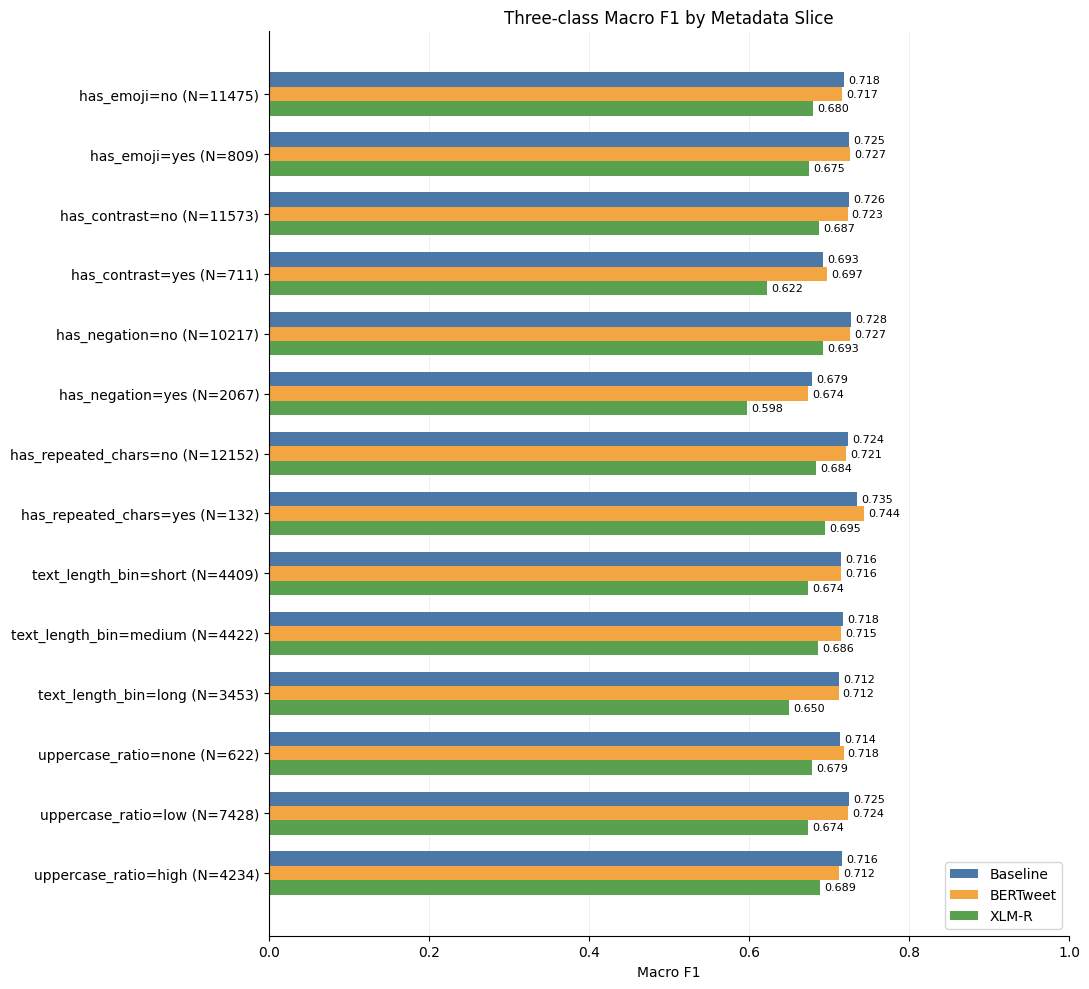

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plot_data = three_class_slices.copy()
plot_data["group"] = (
    plot_data["metadata"] + "=" + plot_data["slice"]
)

group_order = [
    f"{feature}={group}"
    for feature, groups in slice_rules.items()
    for group, _ in groups
]

scores = plot_data.pivot(
    index="group",
    columns="model",
    values="macro_f1",
).reindex(
    index=group_order,
    columns=["baseline", "bertweet", "xlm_roberta"],
)

counts = (
    plot_data[plot_data["model"] == "baseline"]
    .set_index("group")["samples"]
    .reindex(group_order)
)

y = np.arange(len(scores))
bar_height = 0.24

fig, ax = plt.subplots(figsize=(11, 10))

colors = ["#4C78A8", "#F2A541", "#59A14F"]
names = ["Baseline", "BERTweet", "XLM-R"]

for i, (model, label, color) in enumerate(
    zip(scores.columns, names, colors)
):
    bars = ax.barh(
        y + (i - 1) * bar_height,
        scores[model],
        height=bar_height,
        label=label,
        color=color,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels([
    f"{group} (N={int(counts[group])})"
    for group in group_order
])
ax.invert_yaxis()

ax.set_xlim(0, 1)
ax.set_xlabel("Macro F1")
ax.set_title("Three-class Macro F1 by Metadata Slice")
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "slices_three_class_macro_f1.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

### Chart - Adapted PN Macro F1 by Metadata Slice

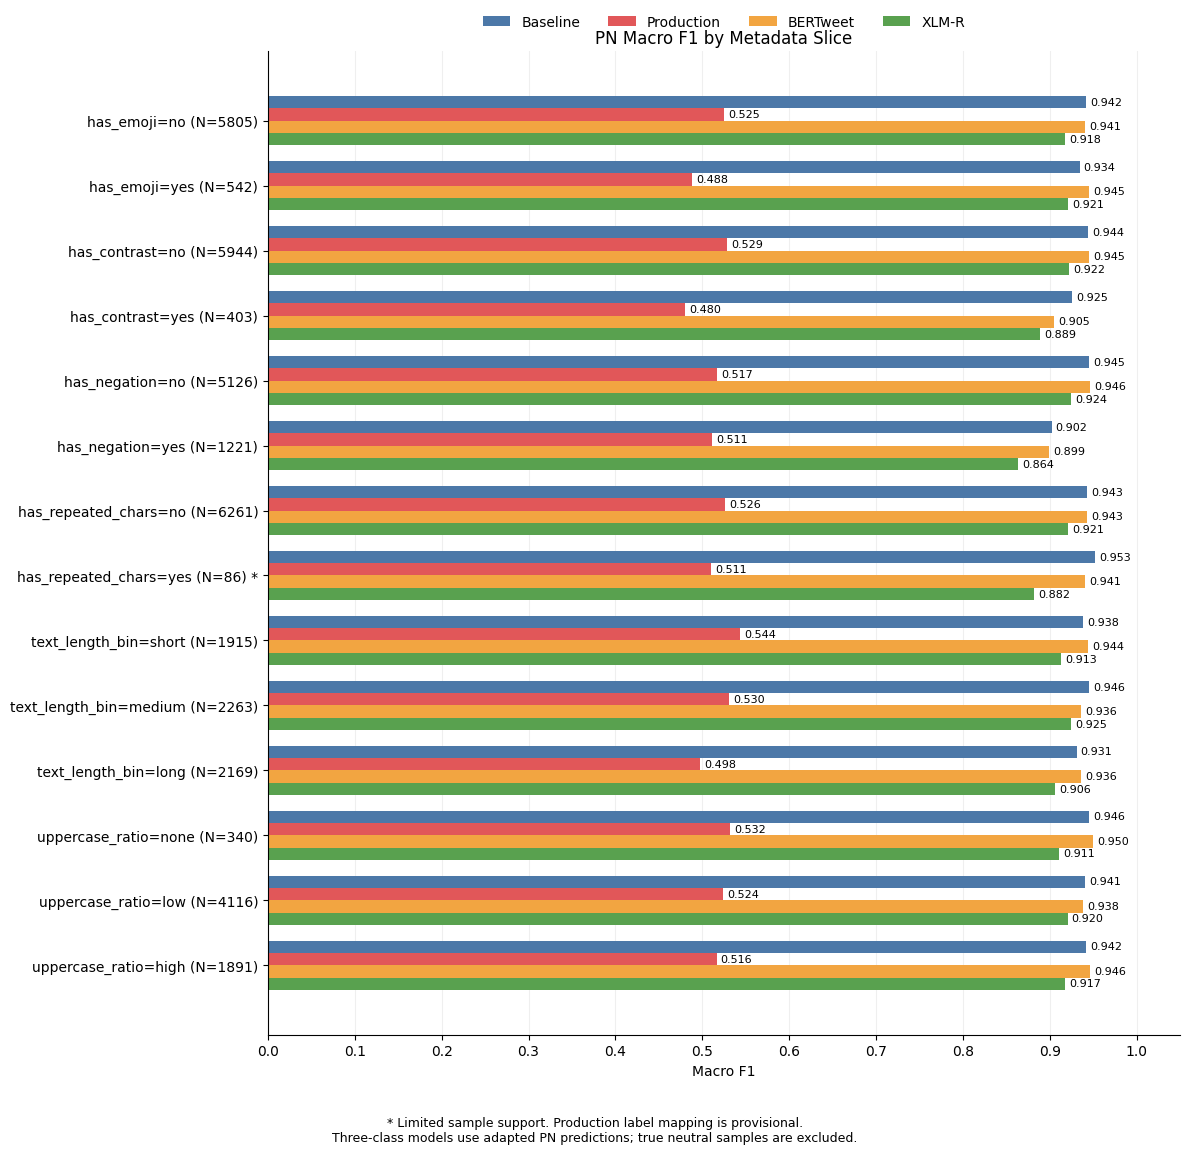

In [30]:
import numpy as np
import matplotlib.pyplot as plt

plot_data = pn_slices.copy()
plot_data["group"] = (
    plot_data["metadata"] + "=" + plot_data["slice"]
)

group_order = [
    f"{feature}={group}"
    for feature, groups in slice_rules.items()
    for group, _ in groups
]

models = ["baseline", "production", "bertweet", "xlm_roberta"]
names = ["Baseline", "Production", "BERTweet", "XLM-R"]
colors = ["#4C78A8", "#E15759", "#F2A541", "#59A14F"]

scores = plot_data.pivot(
    index="group",
    columns="model",
    values="macro_f1",
).reindex(index=group_order, columns=models)

group_info = (
    plot_data[plot_data["model"] == "baseline"]
    .set_index("group")
    .reindex(group_order)
)

labels = [
    f"{group} (N={int(group_info.loc[group, 'samples'])})"
    + (" *" if group_info.loc[group, "small_slice"] else "")
    for group in group_order
]

y = np.arange(len(scores))
bar_height = 0.19

fig, ax = plt.subplots(figsize=(12, 12))

for i, (model, name, color) in enumerate(
    zip(models, names, colors)
):
    bars = ax.barh(
        y + (i - 1.5) * bar_height,
        scores[model],
        height=bar_height,
        label=name,
        color=color,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()

ax.set_xlim(0, 1.05)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_xlabel("Macro F1")
ax.set_title("Adapted PN Macro F1 by Metadata Slice")
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.2)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5, 0.015,
    "* Limited sample support. "
    "Production label mapping is provisional.\n"
    "Three-class models use adapted PN predictions; "
    "true neutral samples are excluded.",
    ha="center",
    fontsize=9,
)

fig.tight_layout(rect=[0, 0.055, 1, 0.97])

path = OUTPUT_DIR / "slices_pn_macro_f1.png"
fig.savefig(path, dpi=200, bbox_inches="tight")

plt.show()

## 13. Initialize W&B

Create a run to record the evaluation setup and saved results.

Keep native three-class evaluation, production native PN evaluation,
and adapted PN comparison clearly separated.

In [ ]:
import wandb

wandb.login()

wandb_run = wandb.init(
    project="KKU3S-Sentiment-M1",
    name="Final_Four_Model_Evaluation",
    notes=(
        "Final evaluation with 6 metadata features and 14 slices. "
        "Native three-class and adapted PN results are reported separately. "
        "Production supports PN only; its label mapping is provisional."
    ),
    config={
        "models": MODEL_IDS,
        "test_samples": len(test_df),
        "pn_samples": int(test_df["label"].isin([0, 2]).sum()),
        "batch_size": BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "metadata": metadata_cols,
        "word_count_thresholds": [
            float(length_low),
            float(length_high),
        ],
        "uppercase_ratio_threshold": UPPERCASE_THRESHOLD,
    },
)

print("W&B run:", wandb_run.url)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: xun-w (xun-w-khon-kaen-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B run: https://wandb.ai/xun-w-khon-kaen-university/KKU3S-Sentiment-M1/runs/ntpb8rb2


## 14. Upload Evaluation Results to W&B

Upload complete native predictions, confidence scores, metadata,
and evaluation metrics.

Keep native three-class results, production native PN results,
and adapted PN comparison separately named.

In [33]:
import pandas as pd
import wandb

# Upload all 12,284 rows per model.
# Increase the table limit explicitly to avoid truncation.
wandb.Table.MAX_ROWS = max(wandb.Table.MAX_ROWS, 20000)

for name in MODEL_IDS:
    df = pd.read_csv(
        OUTPUT_DIR / f"{name}_predictions.csv"
    )
    df["correct_native"] = (
        df["prediction_native"] == df["ground_truth"]
    )

    if name == "production":
        # Neutral is unsupported, rather than scored as an error.
        df.loc[df["label"] == 1, "correct_native"] = None

    wandb_run.log({
        f"predictions_native/{name}": wandb.Table(dataframe=df)
    })
    print(f"{name}: uploaded {len(df)} predictions")

metric_tables = {
    "metrics/native_three_class": three_class_metrics,
    "metrics/production_native_pn": pn_metrics[
        pn_metrics["model"] == "production"
    ],
    "metrics/adapted_pn_comparison": pn_metrics,
    "slices/native_three_class": three_class_slices,
    "slices/adapted_pn_comparison": pn_slices,
}

for key, df in metric_tables.items():
    # Convert unavailable metrics to empty cells.
    clean = df.astype(object).where(df.notna(), None)
    wandb_run.log({key: wandb.Table(dataframe=clean)})

# Archive complete CSV files, including metadata and thresholds.
artifact = wandb.Artifact(
    name="final-evaluation-results",
    type="evaluation",
    description=(
        "Native predictions and six metadata features. "
        "PN comparison uses adapted decoding for three-class models. "
        "Production label mapping is provisional."
    ),
)

for path in sorted(OUTPUT_DIR.glob("*.csv")):
    artifact.add_file(str(path), name=path.name)

wandb_run.log_artifact(artifact)

print("\nResults submitted to W&B.")
print("Run:", wandb_run.url)

baseline: uploaded 12284 predictions


/tmp/ipykernel_1952/2849242477.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["label"] == 1, "correct_native"] = None


production: uploaded 12284 predictions
bertweet: uploaded 12284 predictions
xlm_roberta: uploaded 12284 predictions

Results submitted to W&B.
Run: https://wandb.ai/xun-w-khon-kaen-university/KKU3S-Sentiment-M1/runs/ntpb8rb2


## 15. Upload Slice Comparison Charts

Upload native three-class and adapted PN charts separately.
Scores from these two protocols should not be compared directly.

In [34]:
charts = {
    "charts/native_three_class_macro_f1":
        "slices_three_class_macro_f1.png",
    "charts/adapted_pn_macro_f1":
        "slices_pn_macro_f1.png",
}

for key, filename in charts.items():
    path = OUTPUT_DIR / filename

    if not path.exists():
        print(f"Missing: {filename} — regenerate the chart first.")
        continue

    caption = (
        "Native three-class evaluation."
        if "native_three_class" in key
        else (
            "Adapted PN evaluation: true neutral samples excluded; "
            "three-class models choose between negative and positive. "
            "Production label mapping is provisional."
        )
    )

    wandb_run.log({
        key: wandb.Image(str(path), caption=caption)
    })
    print("Uploaded:", filename)

print("W&B run:", wandb_run.url)

Uploaded: slices_three_class_macro_f1.png
Uploaded: slices_pn_macro_f1.png
W&B run: https://wandb.ai/xun-w-khon-kaen-university/KKU3S-Sentiment-M1/runs/ntpb8rb2


## 16. Inspect Prediction Errors

Inspect up to five native prediction errors per model.
Use true negative/positive samples only for production.

These examples support qualitative analysis and do not represent
the frequency of each error type.

In [35]:
error_parts = []

for name, df in prediction_tables.items():
    eligible = df.copy()

    if name == "production":
        eligible = eligible[eligible["label"].isin([0, 2])]

    errors = eligible[
        eligible["prediction_native"] != eligible["ground_truth"]
    ]

    examples = errors.sample(
        n=min(5, len(errors)),
        random_state=42,
    ).copy()

    examples.insert(0, "model", name)
    error_parts.append(examples)

    print(f"\n{name}: {len(errors)} native errors")
    for row in examples.to_dict("records"):
        print(
            f"\nID={row['sample_id']} | "
            f"True={row['ground_truth']} | "
            f"Predicted={row['prediction_native']} | "
            f"Confidence={row['confidence_native']:.3f}"
        )
        print(row["text"])

error_examples = pd.concat(error_parts, ignore_index=True)

path = OUTPUT_DIR / "error_examples_native.csv"
error_examples.to_csv(path, index=False)

wandb_run.log({
    "analysis/native_error_examples":
        wandb.Table(dataframe=error_examples)
})

print("\nSaved:", path)


baseline: 3417 native errors

ID=7085 | True=negative | Predicted=neutral | Confidence=0.640
@user Fox News: Former ICE agent: I arrested over 1,000 illegal aliens, routinely encountered those with voter registration cards.

ID=8074 | True=neutral | Predicted=negative | Confidence=0.753
#IraqiForces storming Al Zuhour district east of #Mosul #Mosul #Mosuloffensive #MosulOp #Iraq#ISIS…

ID=563 | True=neutral | Predicted=negative | Confidence=0.427
If I just listen to the whole Leonard Cohen catalog one more time, will it start to feel okay? #fuck2016

ID=2395 | True=positive | Predicted=neutral | Confidence=0.863
#jerusalem is now trending in Malaysiahttps://t.co/3Tp6hN0Inf

ID=9968 | True=neutral | Predicted=negative | Confidence=0.924
@user Poor Abby. Fidel dead. Maduro will be overthrown. What's a commie lover to do?

production: 2945 native errors

ID=2407 | True=negative | Predicted=positive | Confidence=0.709
New Low for Dems-@pattonoswalt encourages Terrorists to attack Presiden

### Error Inspection Findings

- **Neutral boundaries:** Baseline, BERTweet, and XLM-R sometimes
  assign sentiment to texts labeled neutral, or predict neutral
  for texts labeled positive or negative. This is consistent with
  their lower neutral recall in the full evaluation.

- **High-confidence errors:** Examples include baseline ID 9968
  (0.924), BERTweet ID 6114 (0.952), and production ID 6559 (0.995).
  High confidence does not guarantee a correct prediction.

- **Context and ambiguity:** Some examples contain political news,
  quotations, or potentially sarcastic language. These may require
  context, and some reference labels are difficult to judge from
  the text alone. The examples do not establish a causal explanation.

- **Production limitations:** Errors were inspected only on true
  negative/positive samples. Its label mapping remains provisional,
  and tokenizer compatibility is unresolved; errors cannot be
  attributed solely to model quality.

Five randomly sampled errors per model provide qualitative examples,
not estimates of error-type frequency. Reference labels were retained.

## 17. Shipping Criteria and Model Selection Report


### 1. Shipping criteria and why these metrics matter


**Reference-based criteria.** Compare a new candidate with the existing reference on the same data and evaluation protocol. Baseline is the comparison reference; production is the current replacement target. We do not require an arbitrary absolute score to declare one candidate the best available.

| Criterion | Purpose | Reference-based requirement |
| --- | --- | --- |
| **1. Macro F1** | Check balanced performance across negative, neutral and positive sentiment. Macro F1 gives each class equal weight, so the largest class does not dominate the score. We also inspect per-class F1 to identify weaknesses hidden by the average. | Prefer Macro F1 at least as high as baseline. A lower score needs a clear benefit in the intended use and an explicit justification. |
| **2. Negative recall** | Find negative feedback that may describe poor service or suspected fraud. Higher recall means fewer actual negative messages are missed. Negative sentiment is a signal for review, not proof of fraud. | Prefer negative recall at least as high as baseline. Check missed-negative counts and recall in the negation and contrast groups before accepting a replacement. |
| **3. Negative precision** | Limit neutral or positive messages incorrectly flagged as negative. Better precision reduces unnecessary review and the risk of unfair action if a flag is used against a seller or service provider. | Prefer negative precision at least as high as baseline. If recall improves but precision falls, report the additional false alerts and justify the trade-off. A negative flag must not automatically trigger an accusation or penalty. |
| **4. Metadata checks** | Check whether performance changes across text length, emoji, negation, contrast, capitalization and repeated letters. Overall scores may hide weaknesses in specific text groups. | Compare Macro F1, negative recall and negative precision with baseline within each group. Explain improvements and regressions, prioritize negation and contrast, and report sample and class supports. Small groups provide limited evidence; a model does not need to win every group to be preferred. |

These are proposed decision rules, not previously approved requirements. Small differences are descriptive; no statistical superiority is claimed. If no new candidate clearly improves the reference under the stated priorities, recommending baseline for further validation is a possible technical outcome; it must not be presented as a new candidate or as retaining the current production model.



### 2. Overall results on the three-class task

The baseline and two new candidates were evaluated on the same **12,284 English TweetEval test texts**: 3,972 negative, 5,937 neutral and 2,375 positive. The figures below use the saved completed run; no new model inference was performed for this report. Scores were recorded to four decimal places and are shown here as percentages.

| Model | Accuracy | Macro F1 | Weighted F1 | Neg. precision | Neg. recall |
| --- | --- | --- | --- | --- | --- |
| Baseline | 72.18 | 72.40 | 72.06 | 68.95 | 80.66 |
| BERTweet | 72.02 | 72.19 | 71.89 | 70.47 | 80.21 |
| XLM-R | 68.19 | 68.42 | 67.66 | 61.50 | 86.93 |


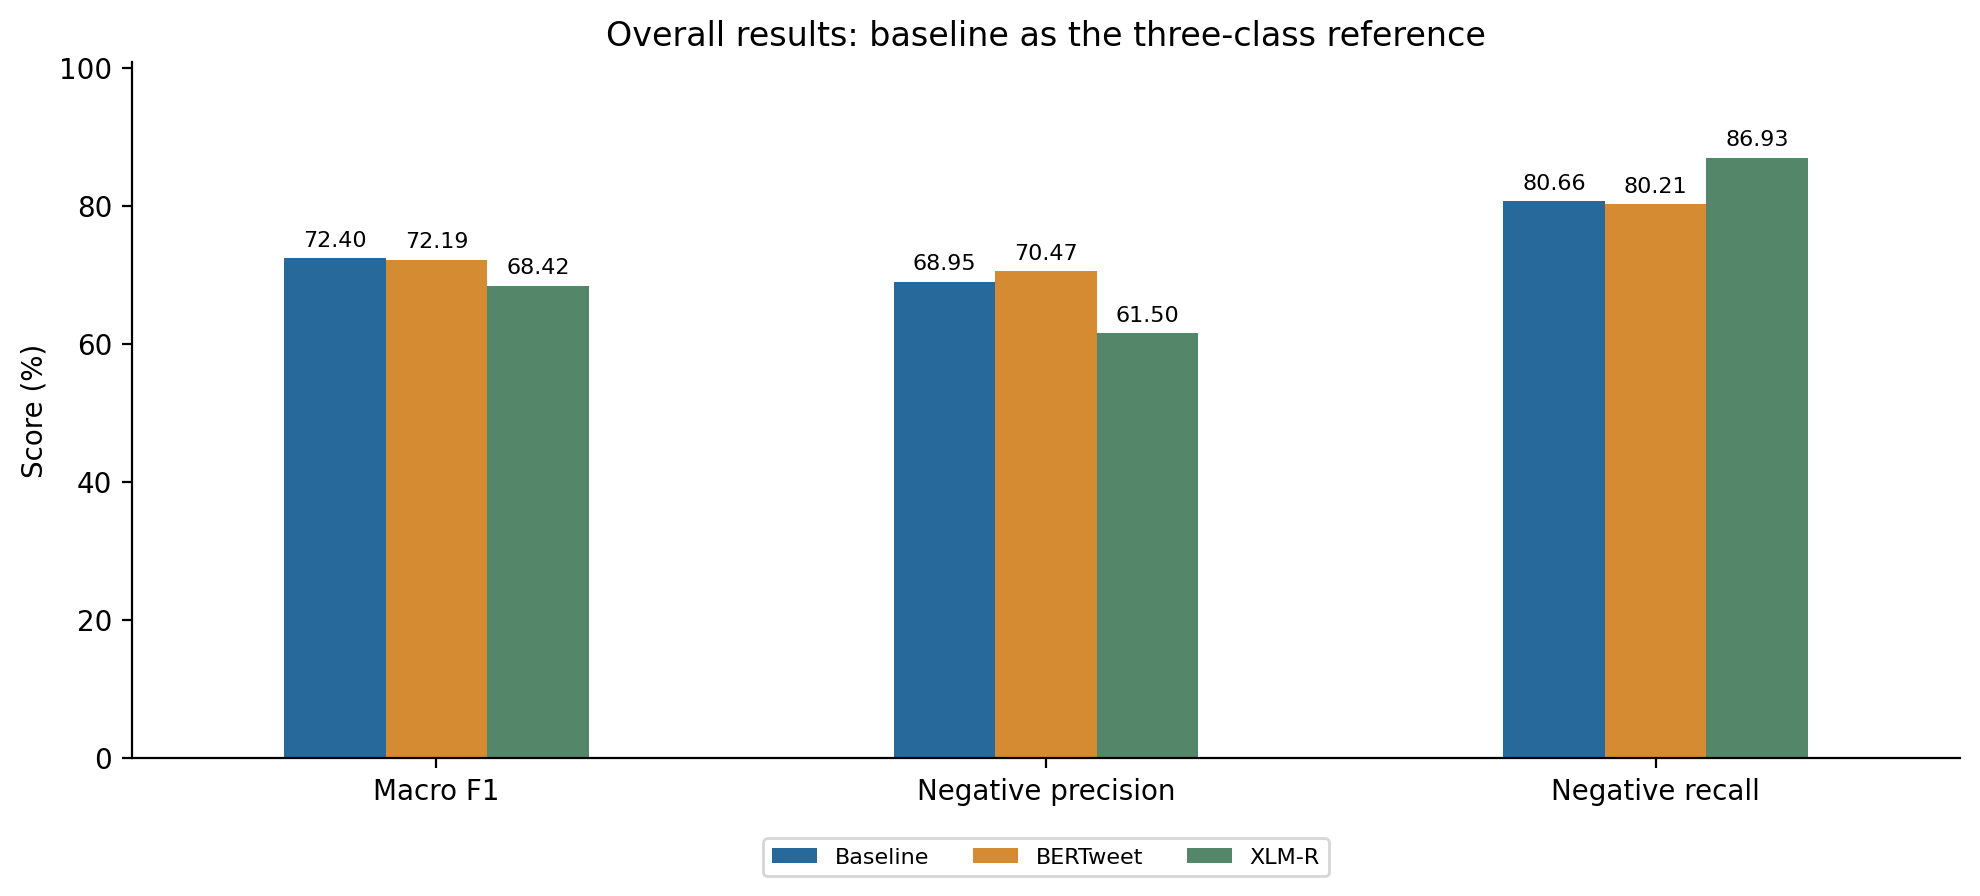

#### Macro F1: baseline leads slightly

Baseline scores **72.40%**, compared with **72.19%** for BERTweet and **68.42%** for XLM-R. Their difference is only **0.21 percentage points**, so this result alone does not establish a reliable superiority of baseline.

#### Accuracy and weighted F1: useful supporting evidence

Accuracy gives the same ordering, but neutral accounts for 48.33% of the test set. An always-neutral classifier would already achieve 48.33% accuracy. Weighted F1 also follows the same ordering and is slightly below Macro F1 because neutral, the largest class, has relatively weak F1. These aggregate scores support keeping baseline and BERTweet on the shortlist.

#### Negative precision and recall: a trade-off

BERTweet has the highest negative precision (**70.47%**), indicating a smaller false-alert fraction among its negative flags. XLM-R has the highest recall (**86.93%**), but precision is only **61.50%**. Baseline is between them at **68.95% precision and 80.66% recall**. For this proposed use, finding more negative texts must be considered together with the extra review work.


### 3. Per-class performance and error burden

| Model | Class | Precision (%) | Recall (%) | F1 (%) | Support |
| --- | --- | --- | --- | --- | --- |
| Baseline | Negative | 68.95 | 80.66 | 74.35 | 3,972 |
| Baseline | Neutral | 75.66 | 65.76 | 70.36 | 5,937 |
| Baseline | Positive | 71.01 | 74.06 | 72.51 | 2,375 |
| BERTweet | Negative | 70.47 | 80.21 | 75.03 | 3,972 |
| BERTweet | Neutral | 75.39 | 65.10 | 69.87 | 5,937 |
| BERTweet | Positive | 68.13 | 75.62 | 71.68 | 2,375 |
| XLM-R | Negative | 61.50 | 86.93 | 72.04 | 3,972 |
| XLM-R | Neutral | 77.05 | 54.96 | 64.16 | 5,937 |
| XLM-R | Positive | 68.24 | 69.94 | 69.08 | 2,375 |

**Negative:** BERTweet has the best F1 (75.03%) because of its precision/recall balance. **Neutral:** XLM-R has high precision (77.05%) but low recall (54.96%); many true neutral texts are missed. Its neutral F1 of 64.16% is 6.20 percentage points below baseline’s 70.36%. **Positive:** BERTweet finds slightly more positives than baseline, but lower precision leaves its F1 lower (71.68% versus 72.51%).

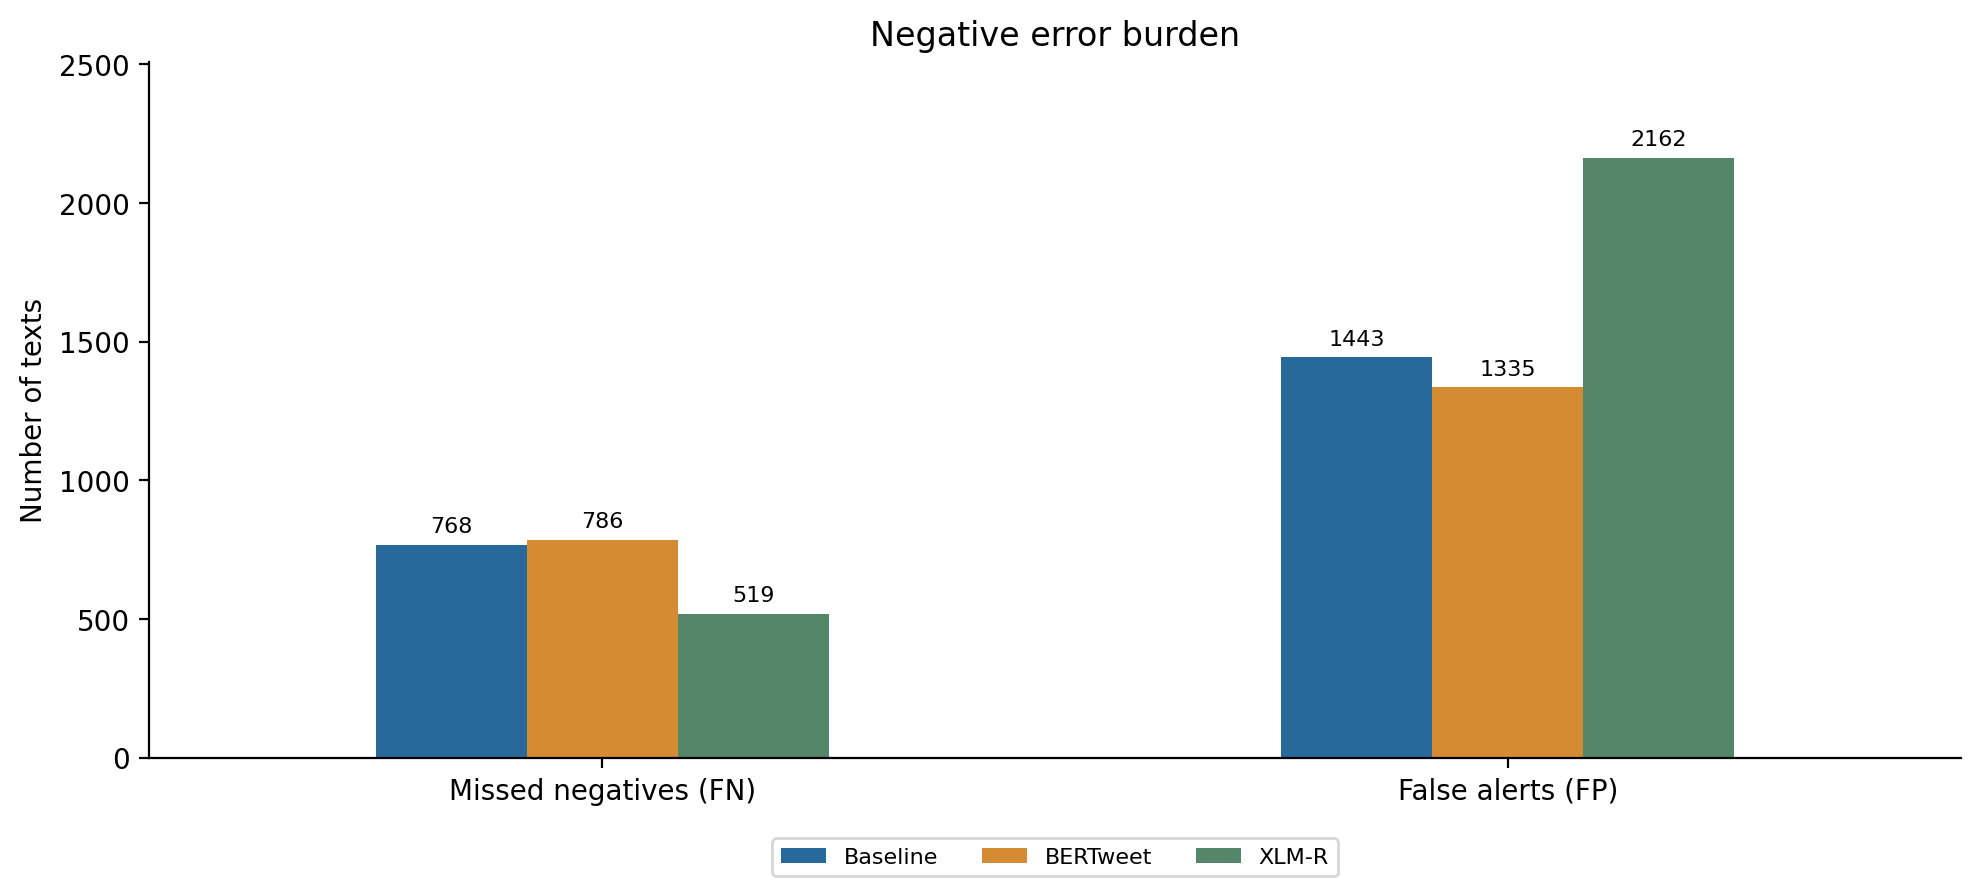


#### What changes if we switch models?

Compared with baseline, BERTweet produces **108 fewer false alerts** (1,335 versus 1,443) but **18 more missed negatives** (786 versus 768). XLM-R misses **249 fewer negatives** than baseline but generates **719 more false alerts**. The total negative flags are 4,647 for baseline, 4,521 for BERTweet and 5,615 for XLM-R.

Most false alerts come from neutral texts: 1,372 for baseline, 1,289 for BERTweet and 2,005 for XLM-R. This explains why XLM-R’s high negative recall should not be interpreted as the best overall choice. We have no agreed monetary or time cost for a missed negative versus a false alert; the preference must therefore state its priorities explicitly.


### 4. Priority metadata: negation and contrast

Metadata is used to divide the test set into evaluation groups; it was not supplied as an input feature to the models. The same text may appear in several groups. We prioritize negation and contrast as relevant language patterns for interpreting feedback, while recognizing that their importance to actual KKU’3S traffic still needs confirmation.

| Slice (support) | Model | Macro F1 (%) | Neg. precision (%) | Neg. recall (%) |
| --- | --- | --- | --- | --- |
| Negation: 2,067 | Baseline | 67.92 | 69.96 | 86.94 |
| Negation: 2,067 | BERTweet | 67.35 | 72.36 | 83.60 |
| Negation: 2,067 | XLM-R | 59.80 | 63.01 | 91.36 |
| Contrast: 711 | Baseline | 69.27 | 68.89 | 83.50 |
| Contrast: 711 | BERTweet | 69.74 | 72.70 | 79.80 |
| Contrast: 711 | XLM-R | 62.20 | 60.23 | 88.22 |

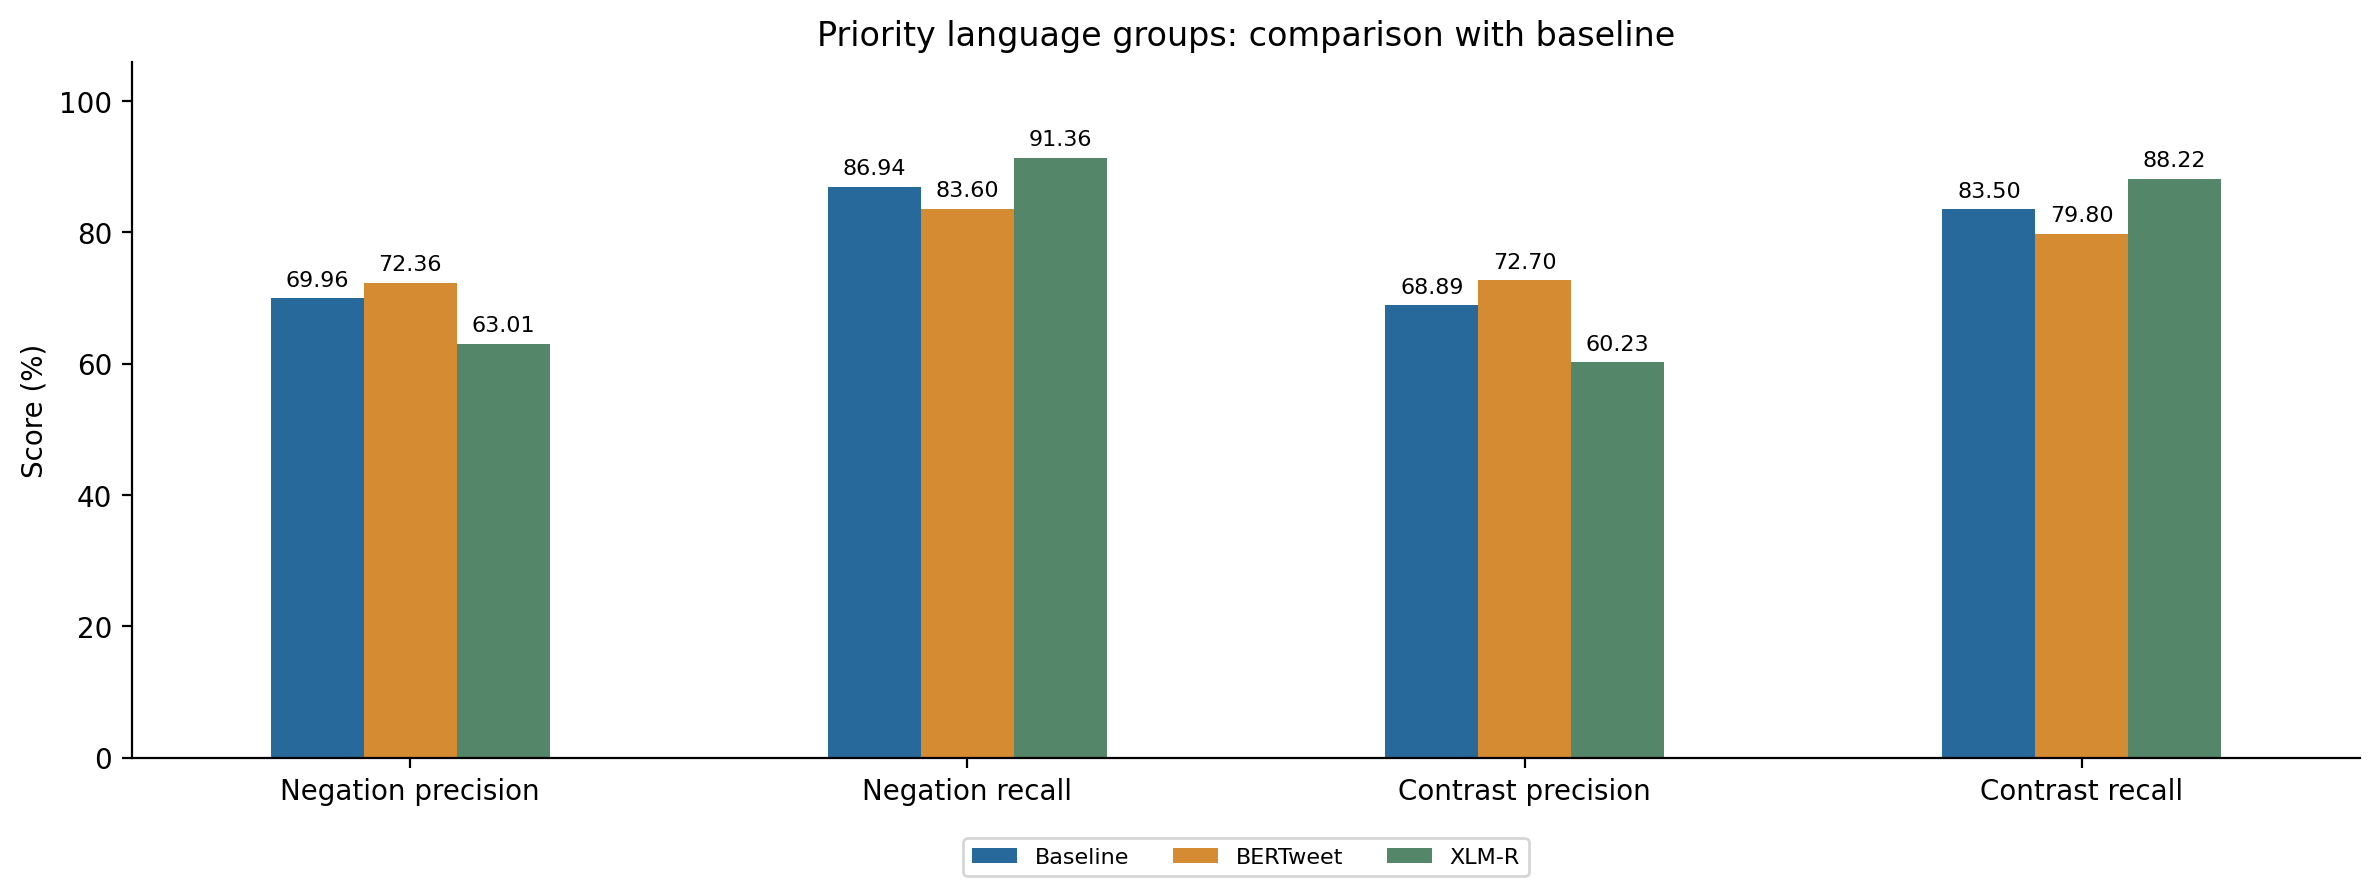


#### Baseline finds more negatives than BERTweet in both groups

In negation, baseline recall is **86.94%** versus **83.60%** for BERTweet: 885 versus 851 correctly detected negatives out of 1,018, a difference of **34 texts**. In contrast, baseline detects 248 of 297 negatives versus 237 for BERTweet, a difference of **11 texts**. Do not add these differences, because the groups overlap.

#### The advantage has a cost

BERTweet has better precision in both groups and slightly better contrast Macro F1. XLM-R has the highest recall, but its Macro F1 and precision are below baseline in both groups. Baseline provides a reasonable balance under our stated priority of finding negative feedback while controlling unnecessary flags.

**Important interpretation:** baseline’s negation Macro F1 falls to 67.92%, while its negative recall rises above its overall recall. A lower slice Macro F1 therefore does not establish weak negative detection. Additional per-class slice metrics would be needed to identify the remaining class errors.


### 5. Other metadata: where the preference weakens

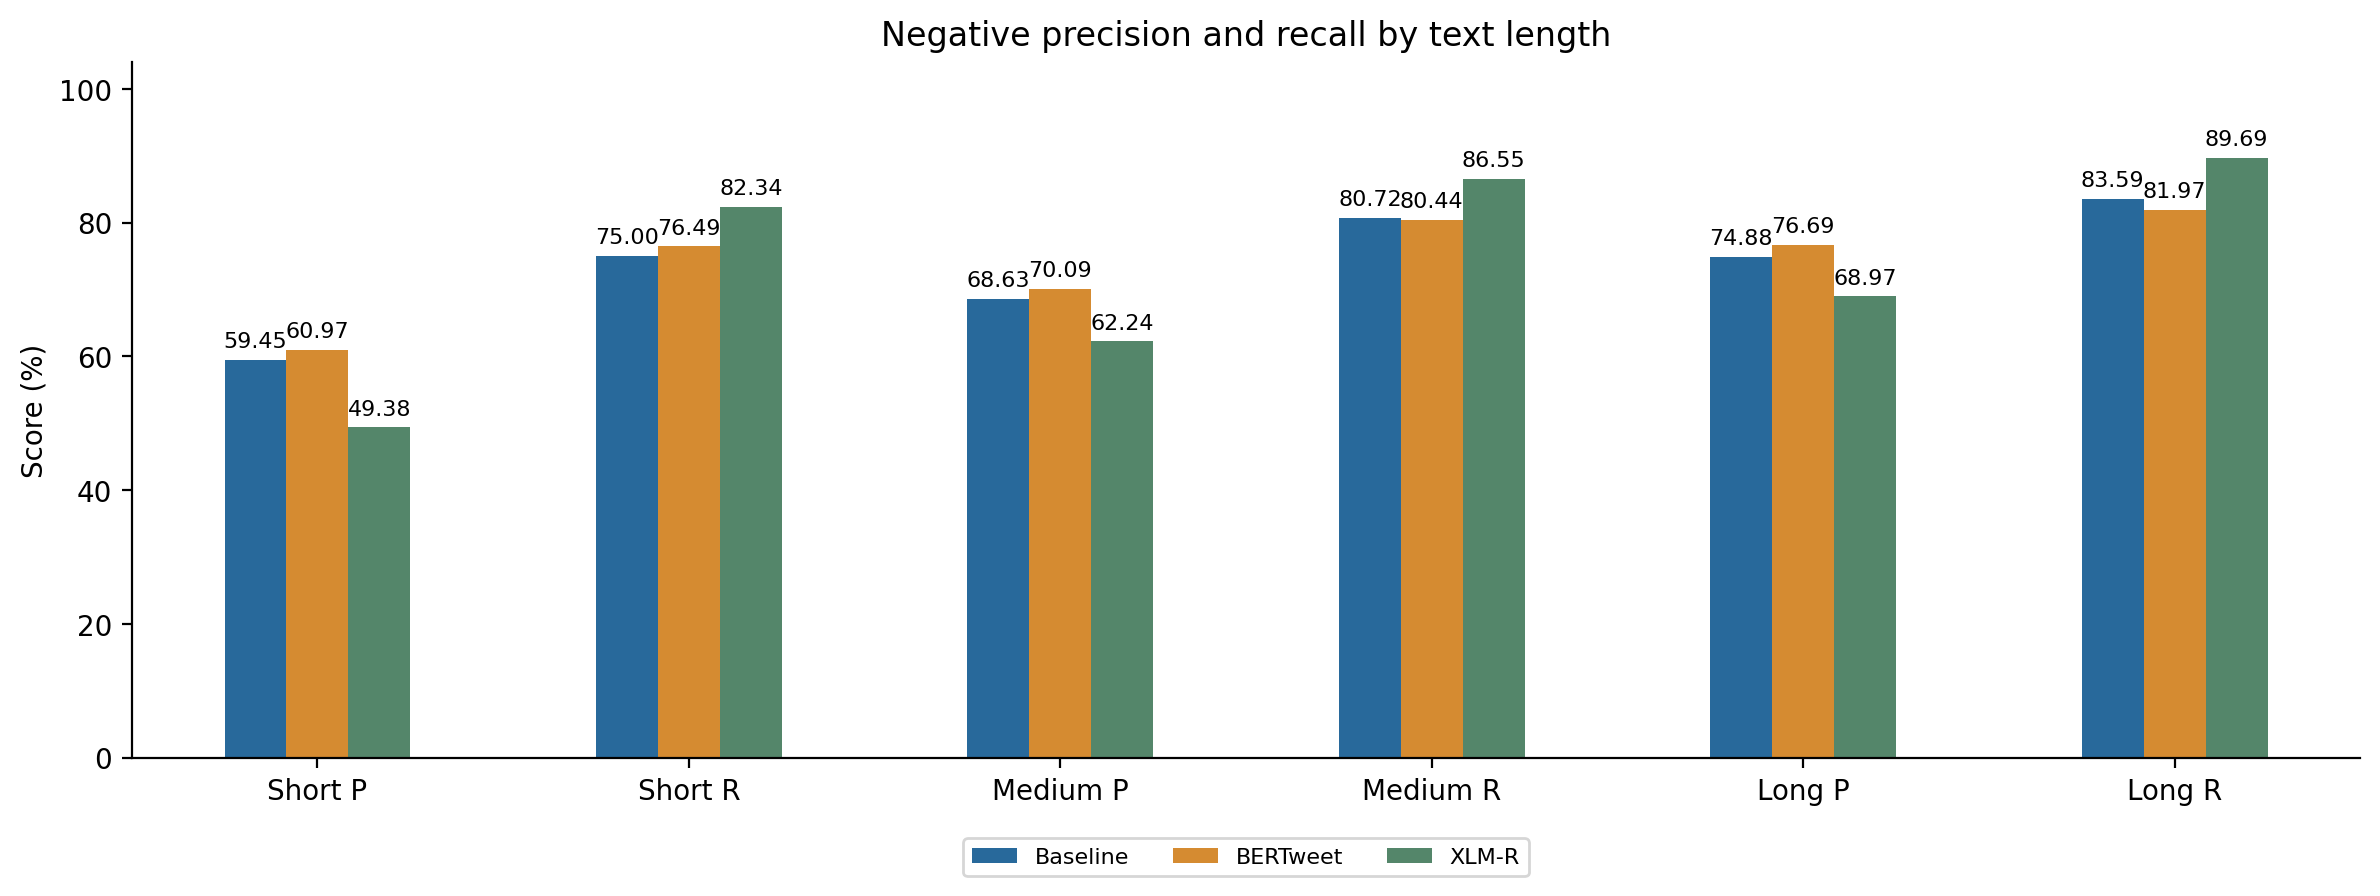

#### Text length reveals a weakness in baseline

For short texts, baseline has **59.45% negative precision** and **75.00% recall**. BERTweet improves both to **60.97%** and **76.49%**. About 41 of every 100 baseline negative flags in this slice were false alerts. BERTweet improves short-text precision by **1.52 percentage points** and recall by **1.49 points** relative to baseline. This is a concrete reason to retain BERTweet as a close alternative and to investigate baseline’s short-text errors.

Baseline’s precision increases to 68.63% for medium and 74.88% for long texts; recall increases to 80.72% and 83.59%. However, the true-negative share also changes: 872/4,409 short texts versus 1,658/3,453 long texts. The graph does not prove that length itself causes the difference.

| Metadata | Observed evidence | Decision implication |
| --- | --- | --- |
| Emoji | Emoji=True: Macro F1 is 72.46% for baseline and 72.67% for BERTweet (809 texts). | The difference is small; emoji does not provide a strong reason to select one of these models. |
| Capitalization | High uppercase: baseline recall 75.51%, BERTweet 77.16%. XLM-R precision is 56.24%. | BERTweet recall is 1.65 points above baseline; XLM-R precision is 9.35 points below baseline. Inspect this trade-off. |
| Repeated letters | True group: Macro F1 is 73.48% / 74.43% / 69.49% for baseline / BERTweet / XLM-R. Only 132 texts (49 negative, 46 neutral, 37 positive). | BERTweet looks promising, but this group provides limited evidence because of its small class supports. One negative example changes recall by about 2.04 points. |

All groups, including False groups, are reported in Appendix A. Their scores are not averaged into a second overall metric because metadata groups overlap. Keyword presence, capitalization and repeated spelling are descriptive indicators; they do not establish sentiment or explain the cause of an error.


### 6. Model preference and shipping decision

**Selected preference: Twitter-RoBERTa (baseline) for future production integration; BERTweet as the preferred new candidate and production alternative.** Baseline is the reference model, not the current production version or one of the two new candidates. BERTweet and XLM-R each improve some outcomes, but neither provides a clear replacement under the reference-based core criteria.

| Model | Change in Macro F1 vs baseline (pp) | Change in negative precision (pp) | Change in negative recall (pp) | Interpretation |
| --- | --- | --- | --- | --- |
| Baseline | 0.00 | 0.00 | 0.00 | Existing reference; highest observed Macro F1. |
| BERTweet | −0.21 | +1.52 | −0.45 | Fewer false alerts, but slightly lower balance and recall. |
| XLM-R | −3.98 | −7.45 | +6.27 | Higher recall at the cost of many more false alerts and weaker balance. |

“pp” means percentage points. Differences use the recorded rounded scores. The small baseline–BERTweet gap is not evidence of statistical superiority.

#### Why select baseline?

Baseline has the highest observed Macro F1 and finds more negatives than BERTweet in both priority groups: 34 more in negation and 11 more in contrast. These overlapping counts must not be added. Relative to XLM-R, baseline reduces false alerts by 719 while missing 249 more negatives. Under our stated preference for balanced negative detection and manageable review work, baseline remains a reasonable reference.

#### Why keep BERTweet as a close alternative?

BERTweet generates 108 fewer false alerts but misses 18 more negatives overall. It improves both precision and recall on short texts. Its priority recall is lower than baseline by 3.34 points for negation and 3.70 points for contrast. A team that places greater weight on reducing false alerts could justify choosing BERTweet; this report has not established the error costs needed to automatically accept that exchange.

#### How should production be used?

All three alternatives outperform the recorded production result on the shared PN protocol, as shown in Appendix B. This is provisional evidence because production’s mapping and tokenizer compatibility still require verification. It does not permit comparing production’s PN score directly with native three-class scores or selecting a three-class winner solely from that gap.

#### Shipping status

**Preferred production model: baseline. Preferred new candidate and alternative: BERTweet. Actual deployment has not been performed.** Neither new candidate dominates baseline across all core metrics. This does not establish that the current production model should be retained. BERTweet is the selected alternative among the two new candidates. Validate the production configuration, confirm the intended languages and use case, investigate metadata regressions, and evaluate representative KKU’3S data before approving release. Relative improvement alone cannot establish that the system is good enough for users.

#### Confidence scope

Confidence is not a deciding criterion for the current human-review workflow. If automated score-based routing is introduced, assess calibration and accuracy/coverage separately.

**Final statement:** We prefer baseline for production integration, with BERTweet as the preferred new candidate and alternative, because neither new candidate clearly improves its balance of Macro F1, negative precision and negative recall. BERTweet is a close alternative for reducing false alerts; XLM-R favors recall at a substantial precision cost. This is a benchmark-based model preference pending deployment validation.


### Appendix A. Complete metadata results

Each model cell shows **Macro F1 / negative precision / negative recall (%)**. N / Neg gives total texts and actual negative texts. These are the 14 groups for each model, covering all six metadata features.

| Metadata group | N / Neg | Baseline<br>F1 / P / R | BERTweet<br>F1 / P / R | XLM-R<br>F1 / P / R |
| --- | --- | --- | --- | --- |
| Emoji: False | 11,475 / 3,785 | 71.85 / 68.95 / 80.69 | 71.68 / 70.50 / 80.24 | 67.96 / 61.61 / 87.13 |
| Emoji: True | 809 / 187 | 72.46 / 68.81 / 80.21 | 72.67 / 69.95 / 79.68 | 67.49 / 59.16 / 82.89 |
| Length: short | 4,409 / 872 | 71.56 / 59.45 / 75.00 | 71.55 / 60.97 / 76.49 | 67.40 / 49.38 / 82.34 |
| Length: medium | 4,422 / 1,442 | 71.79 / 68.63 / 80.72 | 71.51 / 70.09 / 80.44 | 68.65 / 62.24 / 86.55 |
| Length: long | 3,453 / 1,658 | 71.21 / 74.88 / 83.59 | 71.19 / 76.69 / 81.97 | 65.03 / 68.97 / 89.69 |
| Contrast: False | 11,573 / 3,675 | 72.55 / 68.95 / 80.44 | 72.31 / 70.30 / 80.24 | 68.73 / 61.60 / 86.83 |
| Contrast: True | 711 / 297 | 69.27 / 68.89 / 83.50 | 69.74 / 72.70 / 79.80 | 62.20 / 60.23 / 88.22 |
| Negation: False | 10,217 / 2,954 | 72.77 / 68.57 / 78.50 | 72.65 / 69.81 / 79.05 | 69.29 / 60.96 / 85.41 |
| Negation: True | 2,067 / 1,018 | 67.92 / 69.96 / 86.94 | 67.35 / 72.36 / 83.60 | 59.80 / 63.01 / 91.36 |
| Uppercase: none | 622 / 244 | 71.36 / 70.59 / 83.61 | 71.82 / 75.66 / 82.79 | 67.86 / 65.53 / 86.48 |
| Uppercase: low | 7,428 / 2,756 | 72.48 / 69.96 / 82.22 | 72.38 / 71.76 / 81.06 | 67.36 / 63.13 / 88.21 |
| Uppercase: high | 4,234 / 972 | 71.61 / 65.59 / 75.51 | 71.20 / 65.73 / 77.16 | 68.86 / 56.24 / 83.44 |
| Repeated letters: False | 12,152 / 3,923 | 72.37 / 68.89 / 80.65 | 72.14 / 70.38 / 80.14 | 68.38 / 61.41 / 87.05 |
| Repeated letters: True | 132 / 49 | 73.48 / 74.07 / 81.63 | 74.43 / 77.78 / 85.71 | 69.49 / 70.37 / 77.55 |

**Definitions.** Emoji: detection used emoji v0.6.0. Length: whitespace word count. Contrast: whole-word but/however/although/though/yet. Negation: not/never/no/cannot plus common contractions, with curly apostrophes normalized. Uppercase: uppercase letters divided by all letters; none=0, low=(0,10%], high>10%. Repeated letters: at least three consecutive identical letters, case-insensitive; digits and underscores excluded. Exact regexes remain in the executed notebook.

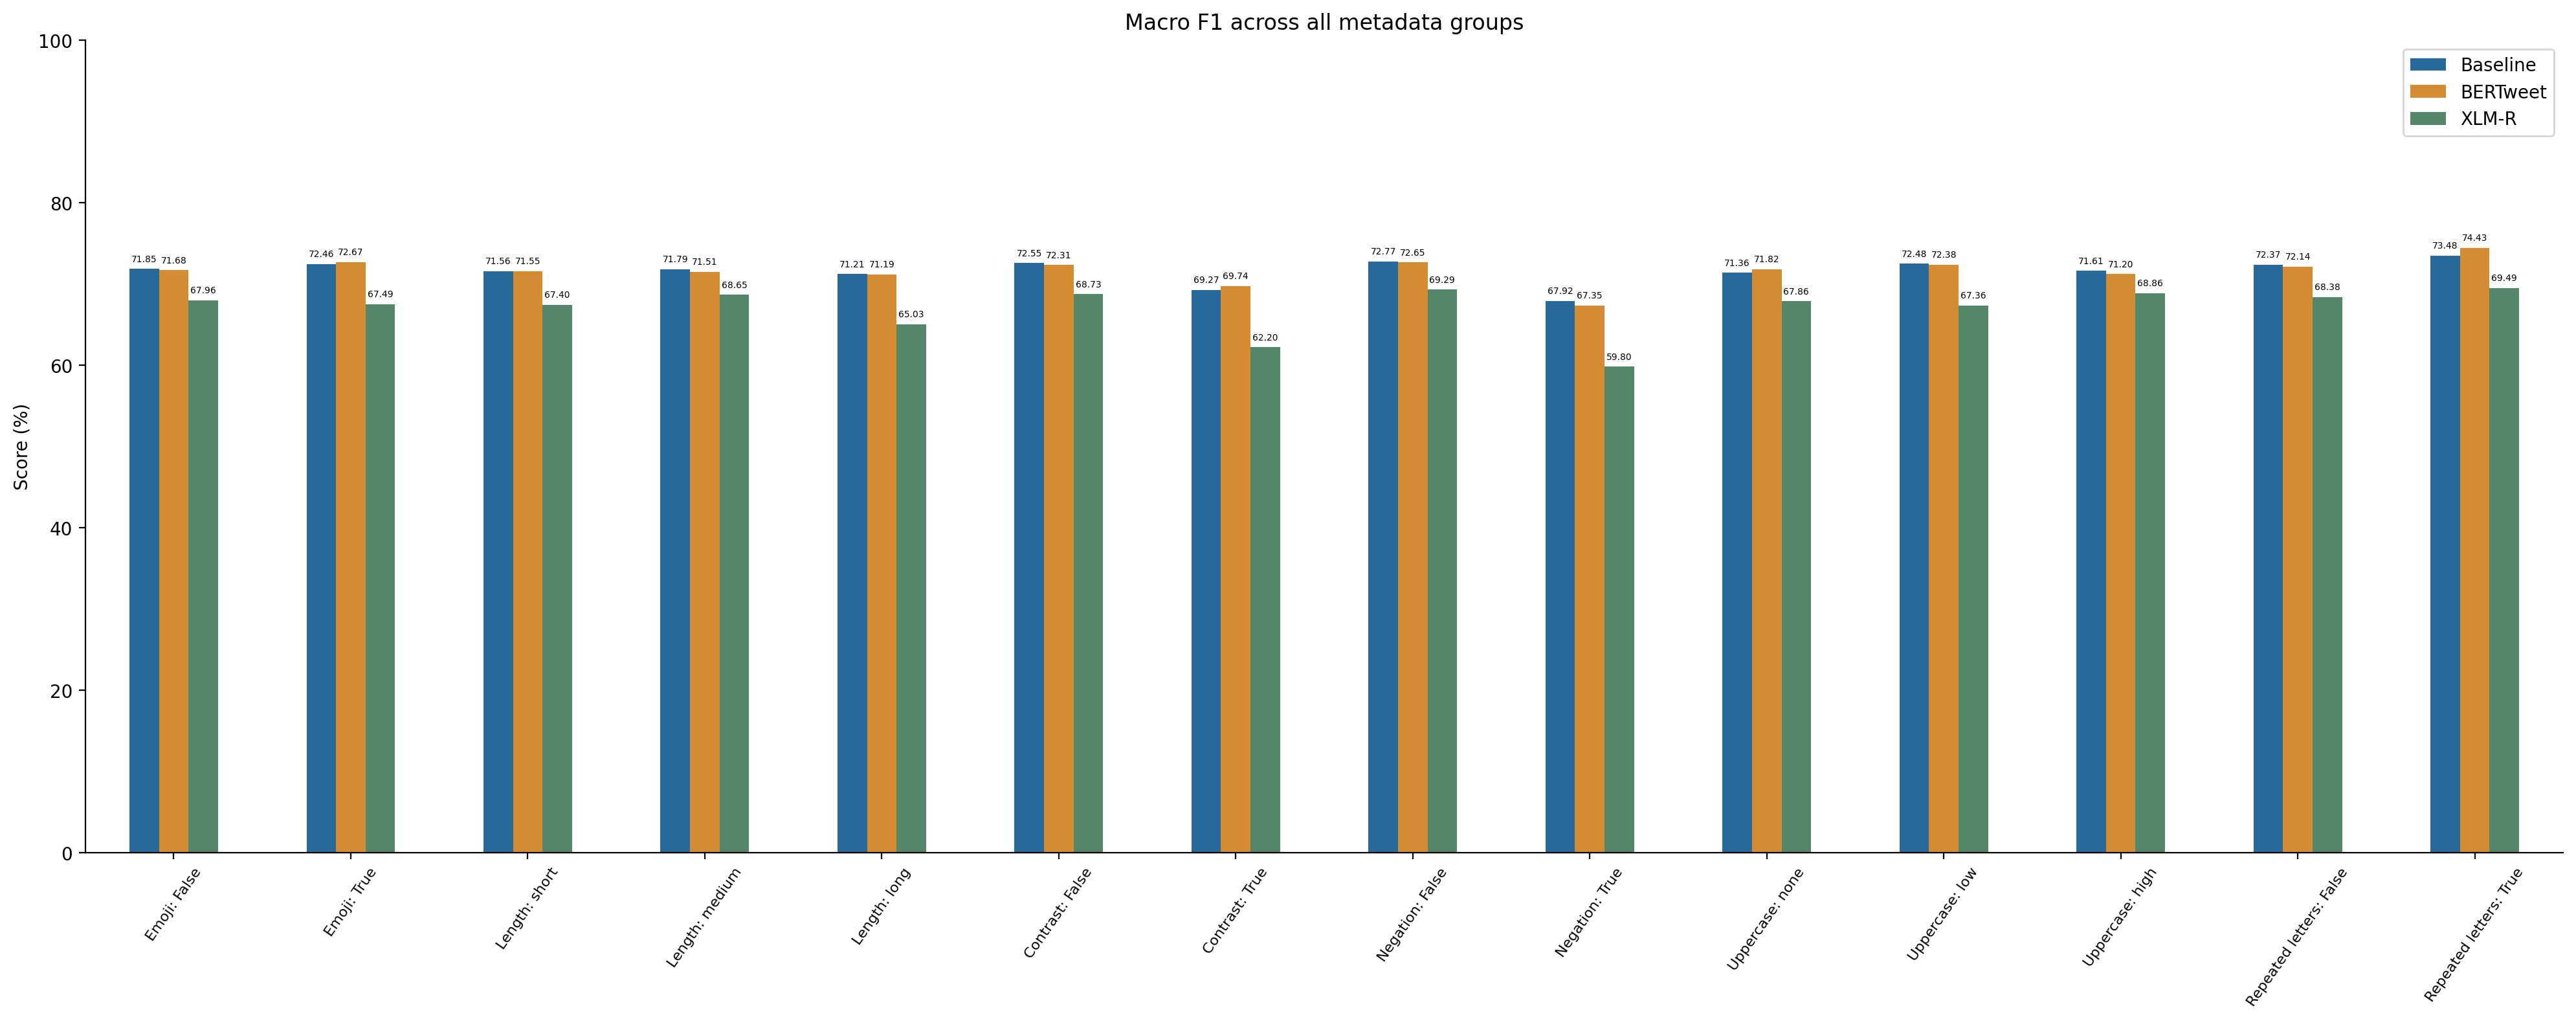

### Appendix B. Adapted positive/negative comparison

This separate protocol removes true-neutral texts and compares p_negative with p_positive, ignoring p_neutral. It uses 6,347 texts and cannot be compared directly with the main three-class task.

| Model | Accuracy (%) | Macro F1 (%) | Neg. P (%) | Neg. R (%) |
| --- | --- | --- | --- | --- |
| Baseline | 94.64 | 94.30 | 96.09 | 95.32 |
| BERTweet | 94.60 | 94.29 | 97.17 | 94.11 |
| XLM-R | 92.63 | 92.08 | 93.39 | 94.94 |
| Production GPT-2 | 53.60 | 52.61 | 65.59 | 54.38 |

Production’s 0/1 label mapping is provisional. Its low adapted PN result should be investigated; it does not alone establish a fair native-task improvement from replacement.

#### Evidence and reproducibility

Source: **FINAL_RUN.ipynb** and saved CSVs in **results/final_run/**. Weighted F1, false-alert/missed-negative counts and all 14 three-class slice results were independently recalculated from the saved native prediction CSVs during integration; model inference was not rerun. The analysis uses these recorded results; it does not claim an independent rerun of the group reference. Settings: batch size 16, maximum 128 tokens, and model-specific preprocessing. English TweetEval may differ from actual KKU’3S data. No paired significance test was available. Reference-based selection rules are project proposals; deployment suitability requires separate evidence.

Relative to production on the **same PN protocol**, baseline improves Macro F1 by 41.69 percentage points, negative precision by 30.50 points and negative recall by 40.94 points. These large recorded gaps should prompt a check of the production configuration before a replacement claim is accepted.

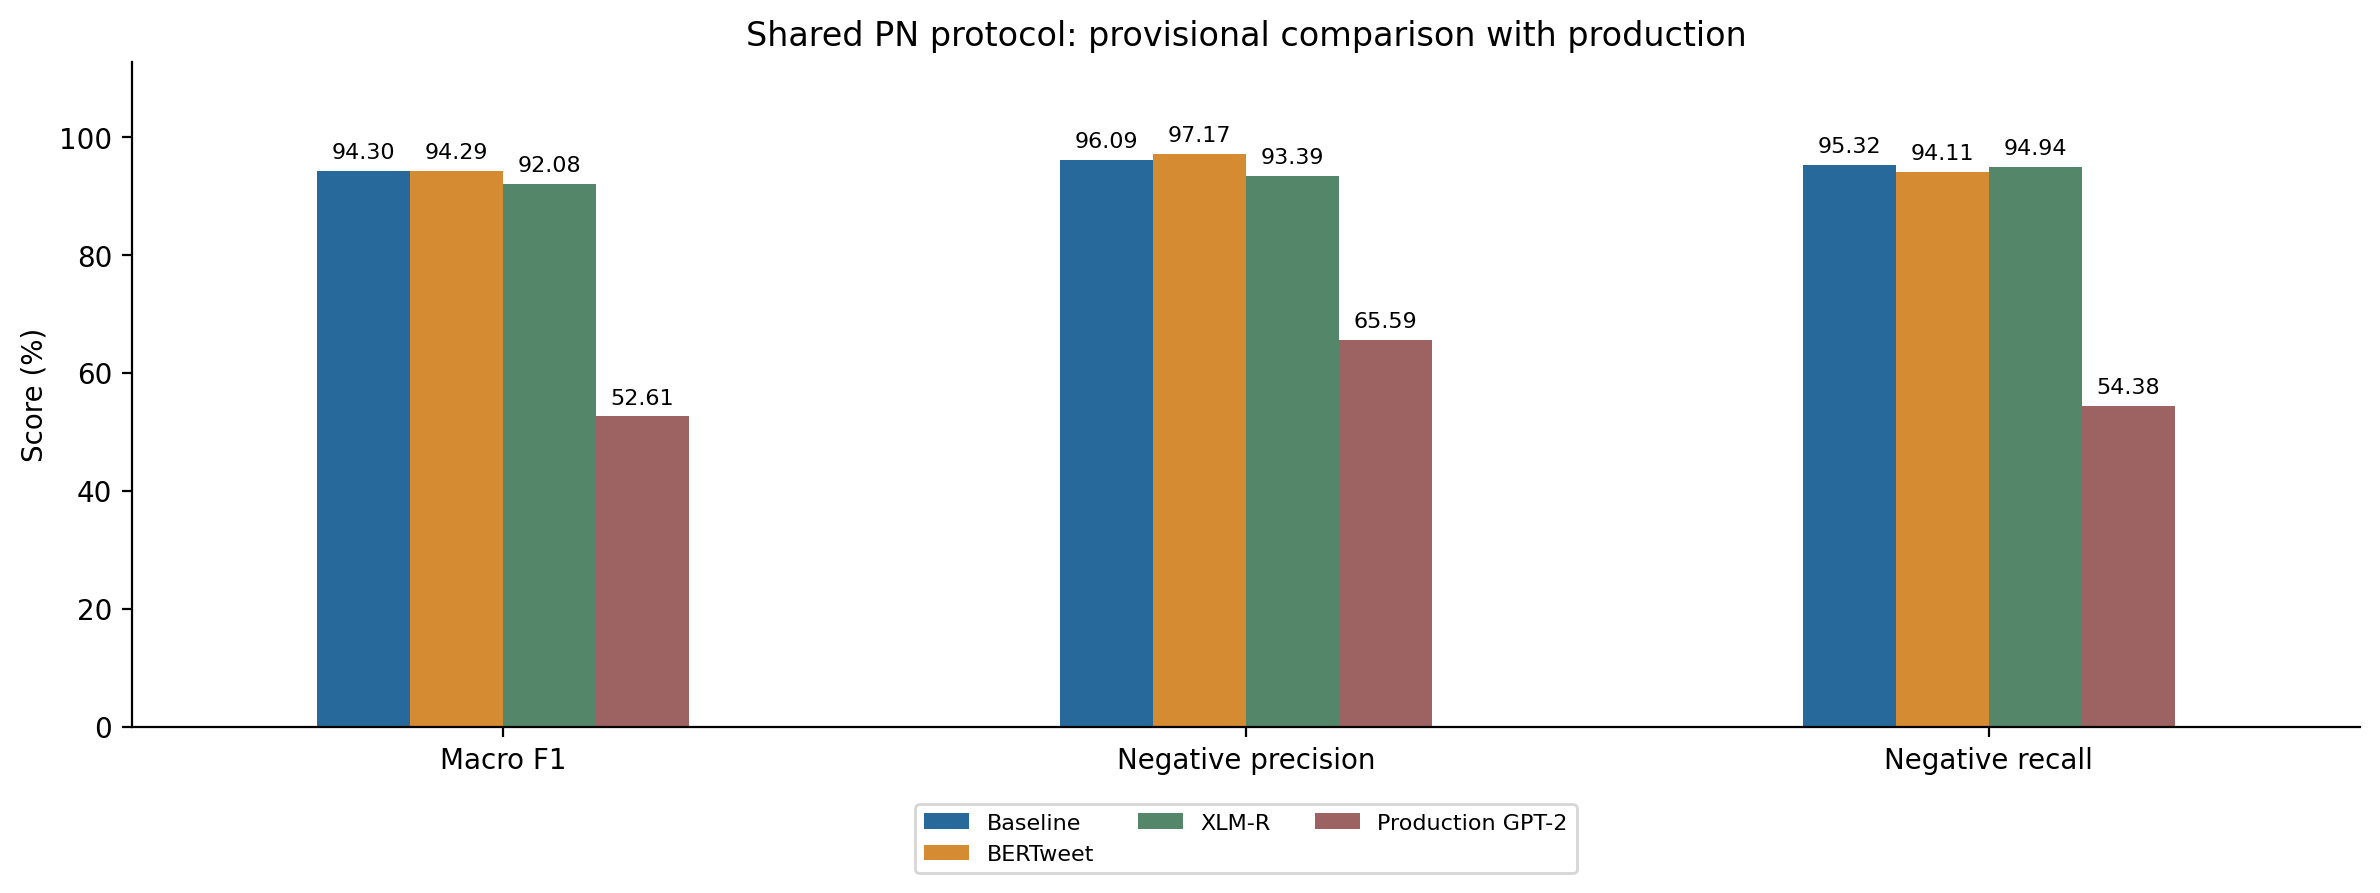


## 18. Integration and Release Plan

This is an offline evaluation, not a deployed system. After team agreement and representative KKU'3S validation, load the selected model with the same tokenizer, preprocessing, label mapping and truncation settings used here. Return native negative/neutral/positive predictions and confidence for human review. Do not convert sentiment flags directly into fraud accusations or penalties.

Monitor negative false alerts, missed negatives, neutral recall, relevant metadata groups, latency and inference failures. Preserve the previous model/configuration as a versioned fallback. If an approved rollout degrades service or quality, restore the previous version; unsupported neutral output must remain explicit. Actual deployment, monitoring and rollback have not been implemented in this notebook.


## 19. Reproducibility

- Use this notebook as the single final entry point; Milestone #1 notebooks remain under docs/history_sources/.
- Run cells in order in Colab with a GPU. Install requirements-final.txt before Step 1; Step 3 also installs emoji 0.6.0 for BERTweet compatibility.
- Use batch size 16, maximum length 128 and the recorded model-specific preprocessing. Metadata is calculated from original text.
- Numerical grouping thresholds are saved in metadata_thresholds.csv; slices overlap and must not be added together.
- W&B login is interactive. Each rerun creates a new run; do not hardcode the completed run ID.
- Recorded experiment: https://wandb.ai/xun-w-khon-kaen-university/KKU3S-Sentiment-M1/runs/ntpb8rb2 (team access required).
- Model and dataset revisions are not pinned, so immutable reproduction is not yet guaranteed.
- Integrated text and Python syntax were checked; a fresh end-to-end GPU run has not been performed after integration.

### Future Work

If time and cost permit, explore predictions from baseline and BERTweet with an additional decision module for disagreements. This is not implemented and does not guarantee improvement. A learned decision module would need separate training and validation data; the current test set must not be used to train it.


## 20. Finish W&B

Close the run after uploads complete, before disconnecting the runtime.


In [ ]:
wandb_run.finish()
